# Notebook 01 — Perfil General del Dataset y Calidad de Datos

## Sistema de Alerta Temprana · IIND-2104 Modelos Probabilísticos · Universidad de los Andes

---

### Propósito de este notebook

Este es el notebook inicial del proyecto. Su objetivo es comprender a fondo la **estructura y calidad del dataset** antes de cualquier análisis estadístico o modelado. Responde tres preguntas fundamentales:

1. **¿Quiénes están en el dataset?** Composición por semestre, era pedagógica y resultado académico.
2. **¿Qué información tenemos disponible?** Cobertura de variables académicas y de engagement según semestre y era.
3. **¿Con qué subconjuntos debemos trabajar?** Definición formal de los subsets de análisis que se utilizarán en todos los notebooks posteriores.

### Datos fuente

| Archivo | Registros | Columnas | Período |
|---------|-----------|----------|---------|
| `dataset_completo_final.csv` | 764 | 77 | 202320 – 202520 (5 semestres) |

El dataset integra dos fuentes:
- **Notas académicas**: Parciales, actividades magistrales, quices, talleres y fases de proyecto (registros académicos de la Universidad de los Andes, anonimizados).
- **Engagement en Bloque Neón**: Tiempo de uso, visitas y temas visitados en la plataforma LMS del curso.

### Importante: las dos eras pedagógicas

El dataset abarca **dos formatos de evaluación** que no son directamente comparables en sus componentes auxiliares:

| Era | Semestres | Evaluaciones continuas | Característica |
|-----|-----------|------------------------|----------------|
| **Formato Antiguo** | 202320, 202410 | Talleres + Fases de proyecto | Trabajo grupal |
| **Formato Nuevo** | 202420, 202510, 202520 | AMs + Quices (número variable) | Mayoritariamente individual |

Los **3 parciales** (70% del curso) son la única evaluación presente y comparable en **todos** los semestres.

In [1]:
# ─── Importaciones y configuración global ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Paleta de colores del proyecto (consistente en todos los notebooks) ──────
PALETA_ESTADO = {
    'APROBÓ':   '#2ecc71',   # Verde
    'REPROBÓ':  '#e74c3c',   # Rojo
    'RETIRADO': '#95a5a6',   # Gris
    'SIN_NOTA': '#f39c12',   # Amarillo-naranja
}
PALETA_ERA = {
    'formato_antiguo': '#2c3e50',  # Azul oscuro
    'formato_nuevo':   '#e67e22',  # Naranja
}
PALETA_SEMESTRE = {
    202320: '#1a3a5c',
    202410: '#2471a3',
    202420: '#e67e22',
    202510: '#ca6f1e',
    202520: '#784212',
}
ORDEN_ESTADOS = ['APROBÓ', 'REPROBÓ', 'RETIRADO', 'SIN_NOTA']

# ── Estilo global de matplotlib ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#f8f9fa',
    'axes.grid':         True,
    'grid.color':        'white',
    'grid.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
})

# ── Carga del dataset ─────────────────────────────────────────────────────────
df = pd.read_csv('../data/dataset_completo_final.csv', encoding='utf-8-sig')

# Ordenar semestres y asegurar tipos
df['semestre'] = df['semestre'].astype(int)
df['estado']   = pd.Categorical(df['estado'], categories=ORDEN_ESTADOS, ordered=True)

print(f"Dataset cargado: {df.shape[0]} estudiantes × {df.shape[1]} columnas")
print(f"Semestres: {sorted(df['semestre'].unique())}")
print(f"Eras: {df['era'].unique().tolist()}")

Dataset cargado: 764 estudiantes × 77 columnas
Semestres: [np.int64(202320), np.int64(202410), np.int64(202420), np.int64(202510), np.int64(202520)]
Eras: ['formato_antiguo', 'formato_nuevo']


---
## Sección 1 — Composición General del Dataset

El primer paso es entender **cuántos estudiantes hay**, **en qué estado terminaron** y cómo se distribuyen a lo largo de los 5 semestres. Esta visión general establece el denominador correcto para todas las tasas que se calcularán en los análisis posteriores.

**Subconjunto utilizado**: `df_all` — los 764 registros completos, ya que aquí interesa la distribución real incluyendo retirados y estudiantes sin nota.

In [2]:
# ─── 1.1 Tabla resumen de composición ────────────────────────────────────────
tabla_composicion = (
    df.groupby(['semestre', 'era', 'estado'], observed=True)
      .size()
      .unstack('estado', fill_value=0)
      .reset_index()
)
tabla_composicion['TOTAL'] = tabla_composicion[ORDEN_ESTADOS].sum(axis=1)

# Tasas
for estado in ORDEN_ESTADOS:
    tabla_composicion[f'% {estado}'] = (
        tabla_composicion[estado] / tabla_composicion['TOTAL'] * 100
    ).round(1)

# Fila totales generales
total_row = pd.DataFrame([{
    'semestre': 'TOTAL', 'era': '—',
    **{e: df['estado'].value_counts().reindex(ORDEN_ESTADOS, fill_value=0)[e] for e in ORDEN_ESTADOS},
    'TOTAL': len(df),
    **{f'% {e}': round(df['estado'].value_counts(normalize=True).reindex(ORDEN_ESTADOS, fill_value=0)[e]*100, 1)
       for e in ORDEN_ESTADOS}
}])

tabla_display = pd.concat([tabla_composicion, total_row], ignore_index=True)

print("=" * 90)
print("COMPOSICIÓN DEL DATASET: ESTUDIANTES POR SEMESTRE Y ESTADO FINAL")
print("=" * 90)
cols_show = ['semestre', 'era', 'TOTAL'] + ORDEN_ESTADOS + [f'% {e}' for e in ORDEN_ESTADOS]
print(tabla_display[cols_show].to_string(index=False))
print("\nNota: SIN_NOTA = registrado en el curso pero sin calificación final")

COMPOSICIÓN DEL DATASET: ESTUDIANTES POR SEMESTRE Y ESTADO FINAL
semestre             era  TOTAL  APROBÓ  REPROBÓ  RETIRADO  SIN_NOTA  % APROBÓ  % REPROBÓ  % RETIRADO  % SIN_NOTA
  202320 formato_antiguo    170     116       27        27         0      68.2       15.9        15.9         0.0
  202410 formato_antiguo    150      68       14        30        38      45.3        9.3        20.0        25.3
  202420   formato_nuevo    164      90       33        40         1      54.9       20.1        24.4         0.6
  202510   formato_nuevo    140      70       47        21         2      50.0       33.6        15.0         1.4
  202520   formato_nuevo    140      69       20        46         5      49.3       14.3        32.9         3.6
   TOTAL               —    764     413      141       164        46      54.1       18.5        21.5         6.0

Nota: SIN_NOTA = registrado en el curso pero sin calificación final


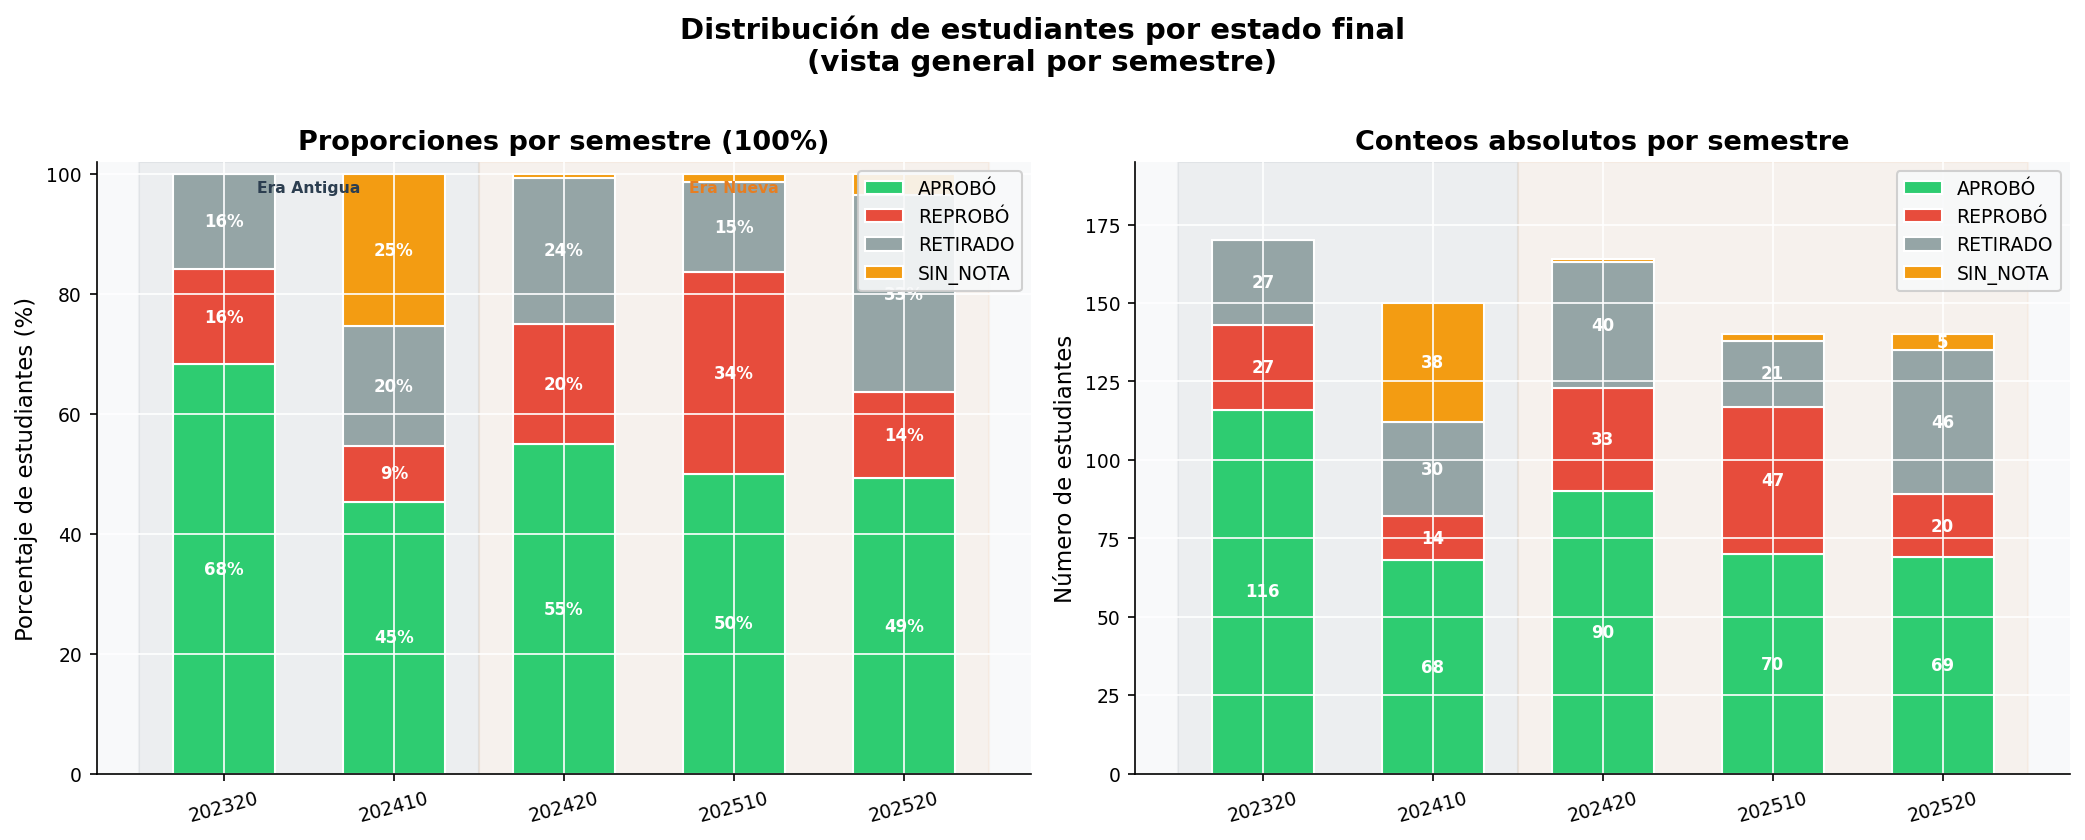

Figura guardada.


In [3]:
# ─── 1.2  Evolución de tasas por semestre (100% stacked bar) ─────────────────
semestres = sorted(df['semestre'].unique())
totales   = df.groupby('semestre').size()
props = (
    df.groupby(['semestre', 'estado'], observed=True)
      .size()
      .unstack('estado', fill_value=0)
      .reindex(columns=ORDEN_ESTADOS, fill_value=0)
      .div(totales, axis=0) * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Distribución de estudiantes por estado final\n(vista general por semestre)',
             fontsize=14, fontweight='bold', y=1.01)

# ── Panel izquierdo: proporciones (100% stacked) ──────────────────────────────
ax = axes[0]
bottom = np.zeros(len(semestres))
x_pos  = np.arange(len(semestres))
for estado in ORDEN_ESTADOS:
    vals = props[estado].values
    bars = ax.bar(x_pos, vals, bottom=bottom,
                  color=PALETA_ESTADO[estado], label=estado, width=0.6, edgecolor='white')
    # Etiqueta dentro de la barra si hay espacio
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax.text(x_pos[i], b + v/2, f'{v:.0f}%',
                    ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_xticks(x_pos)
ax.set_xticklabels([str(s) for s in semestres], rotation=15)
ax.set_ylabel('Porcentaje de estudiantes (%)')
ax.set_ylim(0, 102)
ax.set_title('Proporciones por semestre (100%)', fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)

# Anotación de era
ax.axvspan(-0.5, 1.5, alpha=0.06, color=PALETA_ERA['formato_antiguo'], zorder=0)
ax.axvspan(1.5, 4.5, alpha=0.06, color=PALETA_ERA['formato_nuevo'],   zorder=0)
ax.text(0.5, 97, 'Era Antigua', ha='center', fontsize=7.5,
        color=PALETA_ERA['formato_antiguo'], fontweight='bold')
ax.text(3.0, 97, 'Era Nueva', ha='center', fontsize=7.5,
        color=PALETA_ERA['formato_nuevo'], fontweight='bold')

# ── Panel derecho: conteos absolutos ──────────────────────────────────────────
ax2 = axes[1]
conteos = (
    df.groupby(['semestre', 'estado'], observed=True)
      .size()
      .unstack('estado', fill_value=0)
      .reindex(columns=ORDEN_ESTADOS, fill_value=0)
)
bottom2 = np.zeros(len(semestres))
for estado in ORDEN_ESTADOS:
    vals2 = conteos[estado].values
    ax2.bar(x_pos, vals2, bottom=bottom2,
            color=PALETA_ESTADO[estado], label=estado, width=0.6, edgecolor='white')
    for i, (v, b) in enumerate(zip(vals2, bottom2)):
        if v > 3:
            ax2.text(x_pos[i], b + v/2, str(int(v)),
                     ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom2 += vals2

ax2.set_xticks(x_pos)
ax2.set_xticklabels([str(s) for s in semestres], rotation=15)
ax2.set_ylabel('Número de estudiantes')
ax2.set_ylim(0, 195)
ax2.set_title('Conteos absolutos por semestre', fontweight='bold')
ax2.legend(loc='upper right', framealpha=0.9)
ax2.axvspan(-0.5, 1.5, alpha=0.06, color=PALETA_ERA['formato_antiguo'], zorder=0)
ax2.axvspan(1.5, 4.5, alpha=0.06, color=PALETA_ERA['formato_nuevo'],   zorder=0)

plt.tight_layout()
plt.savefig('../figures/01_composicion_por_semestre.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figura guardada.")

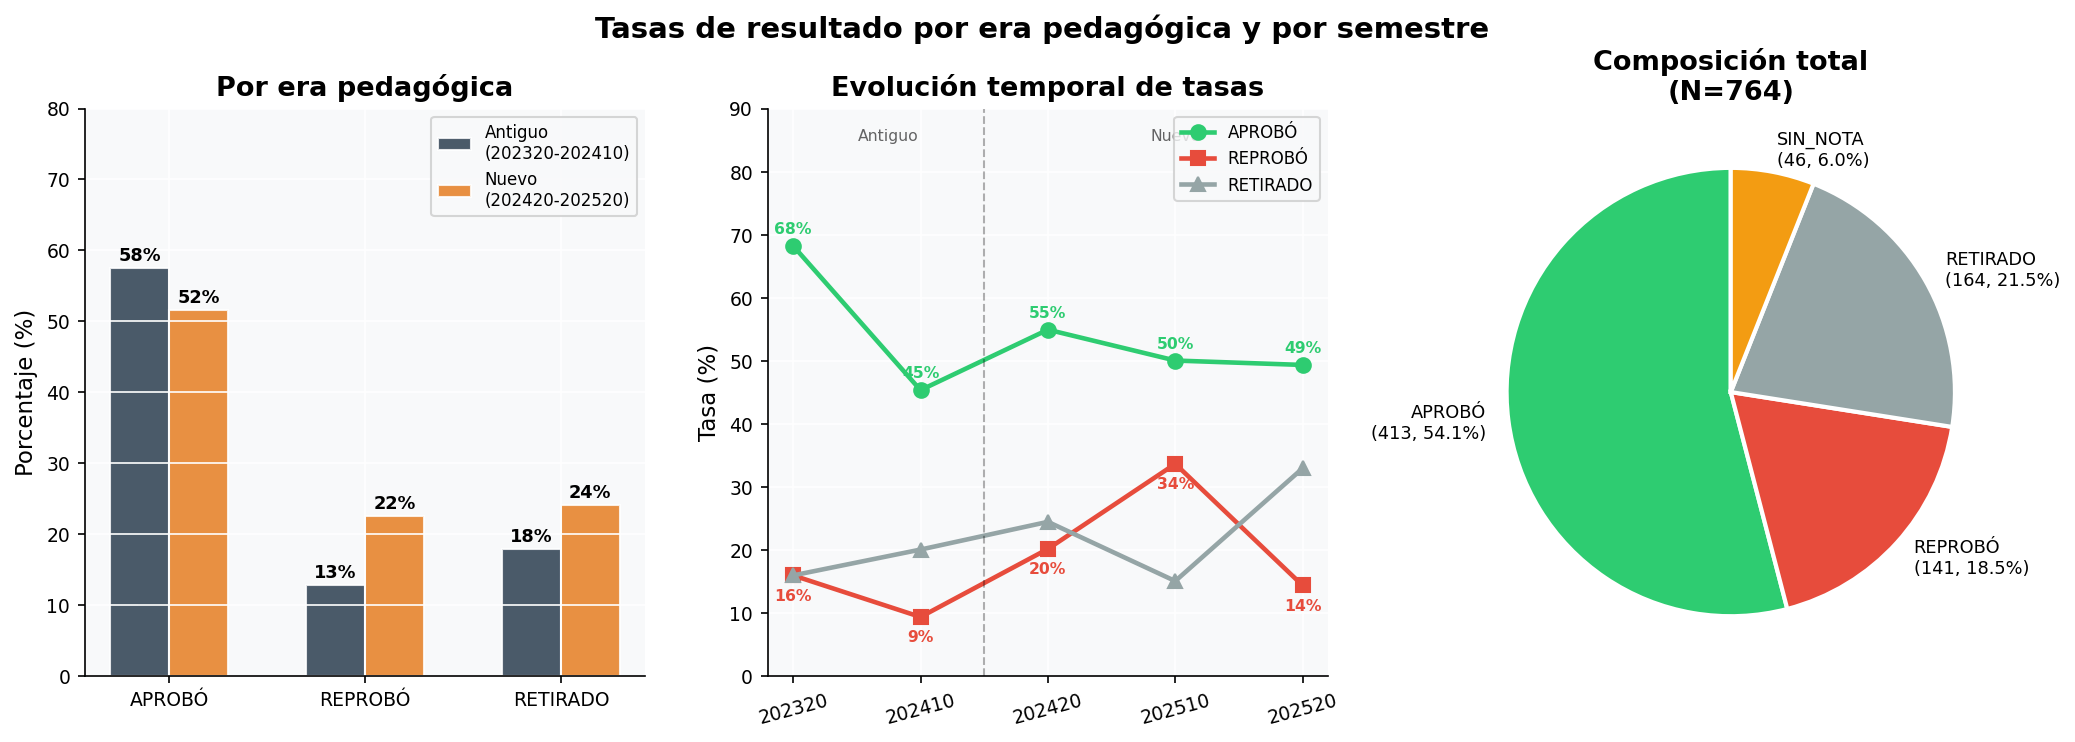

In [4]:
# ─── 1.3 Tasas de aprobación / reprobación / retiro por era ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Tasas de resultado por era pedagógica y por semestre',
             fontsize=14, fontweight='bold')

# Tasas calculadas sobre el total de cada grupo
def tasas_grupo(subdf):
    total = len(subdf)
    return {e: round(subdf['estado'].value_counts().get(e, 0) / total * 100, 1)
            for e in ORDEN_ESTADOS}

# Preparar datos
data_era = {era: tasas_grupo(g) for era, g in df.groupby('era')}
data_sem = {sem: tasas_grupo(g) for sem, g in df.groupby('semestre')}

metricas = ['APROBÓ', 'REPROBÓ', 'RETIRADO']
colores_met = [PALETA_ESTADO[m] for m in metricas]

# Panel 1: Por era
ax = axes[0]
eras_labels = ['Antiguo\n(202320-202410)', 'Nuevo\n(202420-202520)']
eras_keys   = ['formato_antiguo', 'formato_nuevo']
x = np.arange(len(metricas))
w = 0.3
for i, (era_k, era_l) in enumerate(zip(eras_keys, eras_labels)):
    vals = [data_era[era_k][m] for m in metricas]
    bars = ax.bar(x + i*w - w/2, vals, width=w,
                  color=PALETA_ERA[era_k], alpha=0.85, label=era_l, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v:.0f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=9)
ax.set_ylabel('Porcentaje (%)')
ax.set_ylim(0, 80)
ax.set_title('Por era pedagógica', fontweight='bold')
ax.legend(fontsize=8)

# Panel 2: Tasa de aprobación por semestre
ax2 = axes[1]
aprobacion = [data_sem[s]['APROBÓ'] for s in semestres]
reprobacion = [data_sem[s]['REPROBÓ'] for s in semestres]
retiro      = [data_sem[s]['RETIRADO'] for s in semestres]

ax2.plot(range(len(semestres)), aprobacion, 'o-',
         color=PALETA_ESTADO['APROBÓ'], linewidth=2.2, markersize=7, label='APROBÓ')
ax2.plot(range(len(semestres)), reprobacion, 's-',
         color=PALETA_ESTADO['REPROBÓ'], linewidth=2.2, markersize=7, label='REPROBÓ')
ax2.plot(range(len(semestres)), retiro,      '^-',
         color=PALETA_ESTADO['RETIRADO'], linewidth=2.2, markersize=7, label='RETIRADO')

for i, (a, r, rt) in enumerate(zip(aprobacion, reprobacion, retiro)):
    ax2.annotate(f'{a:.0f}%', (i, a), textcoords='offset points', xytext=(0,6),
                 ha='center', fontsize=7.5, color=PALETA_ESTADO['APROBÓ'], fontweight='bold')
    ax2.annotate(f'{r:.0f}%', (i, r), textcoords='offset points', xytext=(0,-12),
                 ha='center', fontsize=7.5, color=PALETA_ESTADO['REPROBÓ'], fontweight='bold')

ax2.set_xticks(range(len(semestres)))
ax2.set_xticklabels([str(s) for s in semestres], rotation=15)
ax2.set_ylabel('Tasa (%)')
ax2.set_ylim(0, 90)
ax2.set_title('Evolución temporal de tasas', fontweight='bold')
ax2.legend(fontsize=8)
ax2.axvline(1.5, color='black', linestyle='--', alpha=0.3, linewidth=1)
ax2.text(0.75, 85, 'Antiguo', ha='center', fontsize=7.5, alpha=0.6)
ax2.text(3.0, 85, 'Nuevo', ha='center', fontsize=7.5, alpha=0.6)

# Panel 3: Treemap visual - composición total
ax3 = axes[2]
totales_estado = df['estado'].value_counts().reindex(ORDEN_ESTADOS)
total_n = totales_estado.sum()
wedges, texts, autotexts = ax3.pie(
    totales_estado.values,
    labels=[f"{e}\n({n}, {n/total_n*100:.1f}%)" for e, n in zip(ORDEN_ESTADOS, totales_estado)],
    colors=[PALETA_ESTADO[e] for e in ORDEN_ESTADOS],
    startangle=90, autopct='',
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 8.5}
)
ax3.set_title(f'Composición total\n(N={total_n})', fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/01_tasas_por_era_semestre.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Sección 2 — Definición de Subconjuntos de Trabajo

Un error frecuente en el análisis de datos educativos es aplicar el mismo dataset a todos los tipos de análisis. En este proyecto **existen razones estructurales** por las cuales ciertos grupos de estudiantes deben excluirse según el análisis que se quiera hacer:

| Situación | Implicación analítica |
|-----------|----------------------|
| Estudiantes **RETIRADOS** | No tienen notas académicas válidas (sus notas son 0 por retiro, no por bajo rendimiento). No tienen engagement en la plataforma (se fueron antes de generar datos). Incluirlos distorsionaría distribuciones de notas y correlaciones. |
| Estudiantes **SIN_NOTA** | Registrados oficialmente pero sin calificación final. Son un caso ambiguo: pueden tener parciales pero no nota_100. Se excluyen del análisis de rendimiento final. |
| Engagement **= 0** en activos | Un pequeño grupo de estudiantes activos (APROBÓ/REPROBÓ) tiene engagement cero, especialmente en los primeros semestres cuando el registro en la plataforma era más incompleto. Para análisis puramente de engagement se excluyen, pero para análisis de riesgo se pueden tratar como señal extrema. |

### Los 4 subconjuntos del proyecto

Se definen a continuación los subconjuntos que se reutilizarán en todos los notebooks:

In [5]:
# ─── Definición oficial de subconjuntos ──────────────────────────────────────

# 1. df_all: dataset completo sin ningún filtro
df_all = df.copy()

# 2. df_activos: excluye RETIRADO y SIN_NOTA
#    Uso: análisis de distribuciones de notas, trayectorias académicas, rendimiento
df_activos = df[~df['estado'].isin(['RETIRADO', 'SIN_NOTA'])].copy()

# 3. df_engagement: cualquier estudiante con engagement > 0 en la plataforma
#    Uso: análisis de comportamiento en la plataforma, patrones de uso
df_engagement = df[df['engagement_hasta_p1'] > 0].copy()

# 4. df_activos_engagement: activos (APROBÓ/REPROBÓ) con engagement > 0
#    Uso: correlaciones nota-engagement, feature engineering para modelos ML
df_activos_engagement = df[
    (~df['estado'].isin(['RETIRADO', 'SIN_NOTA'])) &
    (df['engagement_hasta_p1'] > 0)
].copy()

# ── Resumen de subconjuntos ───────────────────────────────────────────────────
print("=" * 70)
print("SUBCONJUNTOS DE TRABAJO")
print("=" * 70)

subsets = [
    ('df_all',                  df_all,                'Todos los registros'),
    ('df_activos',              df_activos,            'Excluye RETIRADO y SIN_NOTA'),
    ('df_engagement',           df_engagement,         'Engagement > 0 (cualquier estado)'),
    ('df_activos_engagement',   df_activos_engagement, 'Activos con engagement > 0'),
]
for nombre, sub, desc in subsets:
    estados = sub['estado'].value_counts().reindex(ORDEN_ESTADOS, fill_value=0)
    print(f"\n{nombre} (N={len(sub)})")
    print(f"  Descripción : {desc}")
    print(f"  Composición : ", end='')
    print(' | '.join([f"{e}: {n}" for e, n in estados.items() if n > 0]))

print("\n" + "=" * 70)

SUBCONJUNTOS DE TRABAJO

df_all (N=764)
  Descripción : Todos los registros
  Composición : APROBÓ: 413 | REPROBÓ: 141 | RETIRADO: 164 | SIN_NOTA: 46

df_activos (N=554)
  Descripción : Excluye RETIRADO y SIN_NOTA
  Composición : APROBÓ: 413 | REPROBÓ: 141

df_engagement (N=545)
  Descripción : Engagement > 0 (cualquier estado)
  Composición : APROBÓ: 373 | REPROBÓ: 129 | SIN_NOTA: 43

df_activos_engagement (N=502)
  Descripción : Activos con engagement > 0
  Composición : APROBÓ: 373 | REPROBÓ: 129



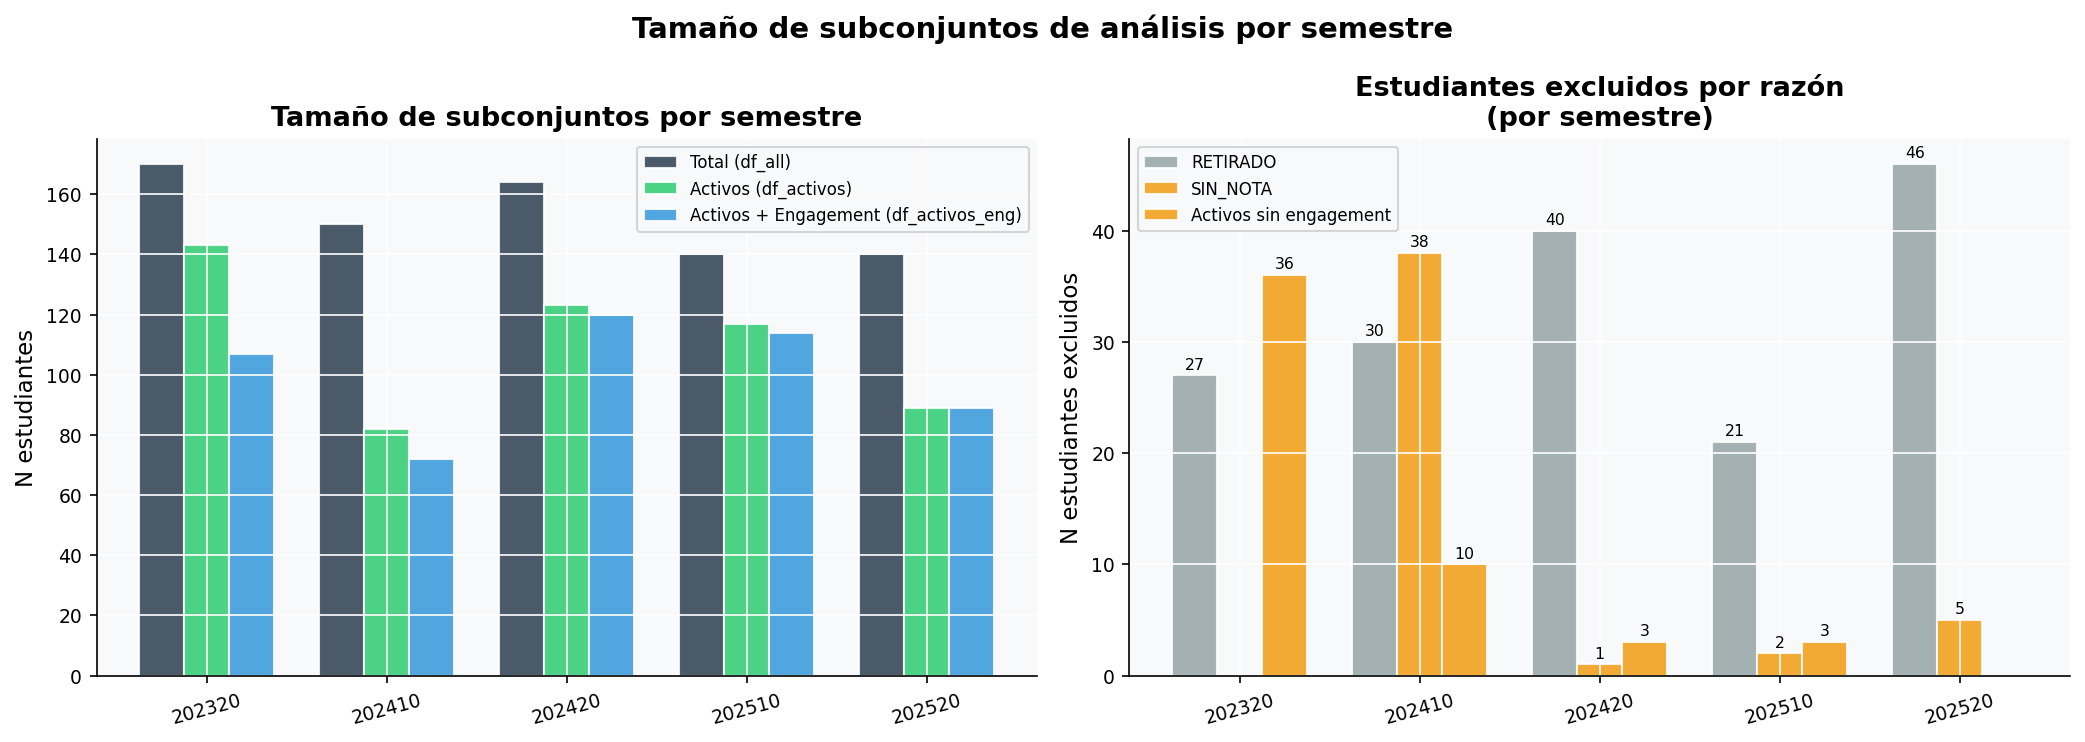

Nota: 'Activos sin engagement' aplica sólo a formato antiguo principalmente.


In [6]:
# ─── Visualización de tamaños de subconjuntos por semestre ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tamaño de subconjuntos de análisis por semestre',
             fontsize=14, fontweight='bold')

subset_info = {
    'df_all':              (df_all,               '#2c3e50', 'Total (df_all)'),
    'df_activos':          (df_activos,            '#2ecc71', 'Activos (df_activos)'),
    'df_activos_eng':      (df_activos_engagement, '#3498db', 'Activos + Engagement (df_activos_eng)'),
}
subset_retiro = {
    'RETIRADO':   (df_all[df_all['estado']=='RETIRADO'],  PALETA_ESTADO['RETIRADO'],  'RETIRADO'),
    'SIN_NOTA':   (df_all[df_all['estado']=='SIN_NOTA'],  PALETA_ESTADO['SIN_NOTA'],  'SIN_NOTA'),
    'Sin eng.':   (df_activos[df_activos['engagement_hasta_p1']==0], '#f39c12', 'Activos sin engagement'),
}

# Panel 1: tamaños absolutos
ax = axes[0]
x = np.arange(len(semestres))
w = 0.25
for j, (key, (sub, color, label)) in enumerate(subset_info.items()):
    counts = sub.groupby('semestre').size().reindex(semestres, fill_value=0)
    ax.bar(x + j*w - w, counts.values, width=w, color=color, alpha=0.85,
           label=label, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in semestres], rotation=15)
ax.set_ylabel('N estudiantes')
ax.set_title('Tamaño de subconjuntos por semestre', fontweight='bold')
ax.legend(fontsize=8)

# Panel 2: estudiantes excluidos de cada subconjunto
ax2 = axes[1]
x2 = np.arange(len(semestres))
w2 = 0.25
for j, (key, (sub, color, label)) in enumerate(subset_retiro.items()):
    counts = sub.groupby('semestre').size().reindex(semestres, fill_value=0)
    ax2.bar(x2 + j*w2 - w2, counts.values, width=w2, color=color, alpha=0.85,
            label=label, edgecolor='white')
    for i, v in enumerate(counts.values):
        if v > 0:
            ax2.text(x2[i] + j*w2 - w2, v + 0.3, str(int(v)),
                     ha='center', va='bottom', fontsize=7.5)
ax2.set_xticks(x2)
ax2.set_xticklabels([str(s) for s in semestres], rotation=15)
ax2.set_ylabel('N estudiantes excluidos')
ax2.set_title('Estudiantes excluidos por razón\n(por semestre)', fontweight='bold')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/01_subconjuntos_por_semestre.png', bbox_inches='tight', dpi=150)
plt.show()
print("Nota: 'Activos sin engagement' aplica sólo a formato antiguo principalmente.")

---
## Sección 3 — Mapa de Nulos y Cobertura de Variables

Antes de cualquier análisis, es crítico entender qué variables están disponibles en cada semestre. En este dataset existen dos tipos de valores nulos:

**Nulos estructurales (esperados):**
- `fase_1`, `fase_2`, `taller_1/2/3`: Solo existen en formato antiguo (202320, 202410). Son `NaN` en formato nuevo por diseño.
- `am_1` a `am_6`, `quiz_1` a `quiz_6`: Solo existen en formato nuevo. Además, el número de AMs y quices varía entre semestres.
- Engagement de estudiantes retirados: Su engagement es 0 (no nulo), ya que nunca usaron la plataforma.

**Nulos potencialmente problemáticos:**
- `parcial_2`, `parcial_3` nulos en activos: Podría indicar retiro tardío no registrado o dato faltante real.
- `nota_100` nula en SIN_NOTA: Estos estudiantes no tienen nota final calculada por razones administrativas.

El objetivo de esta sección es visualizar el patrón completo de nulos para identificar exactamente qué información se puede usar en cada análisis.

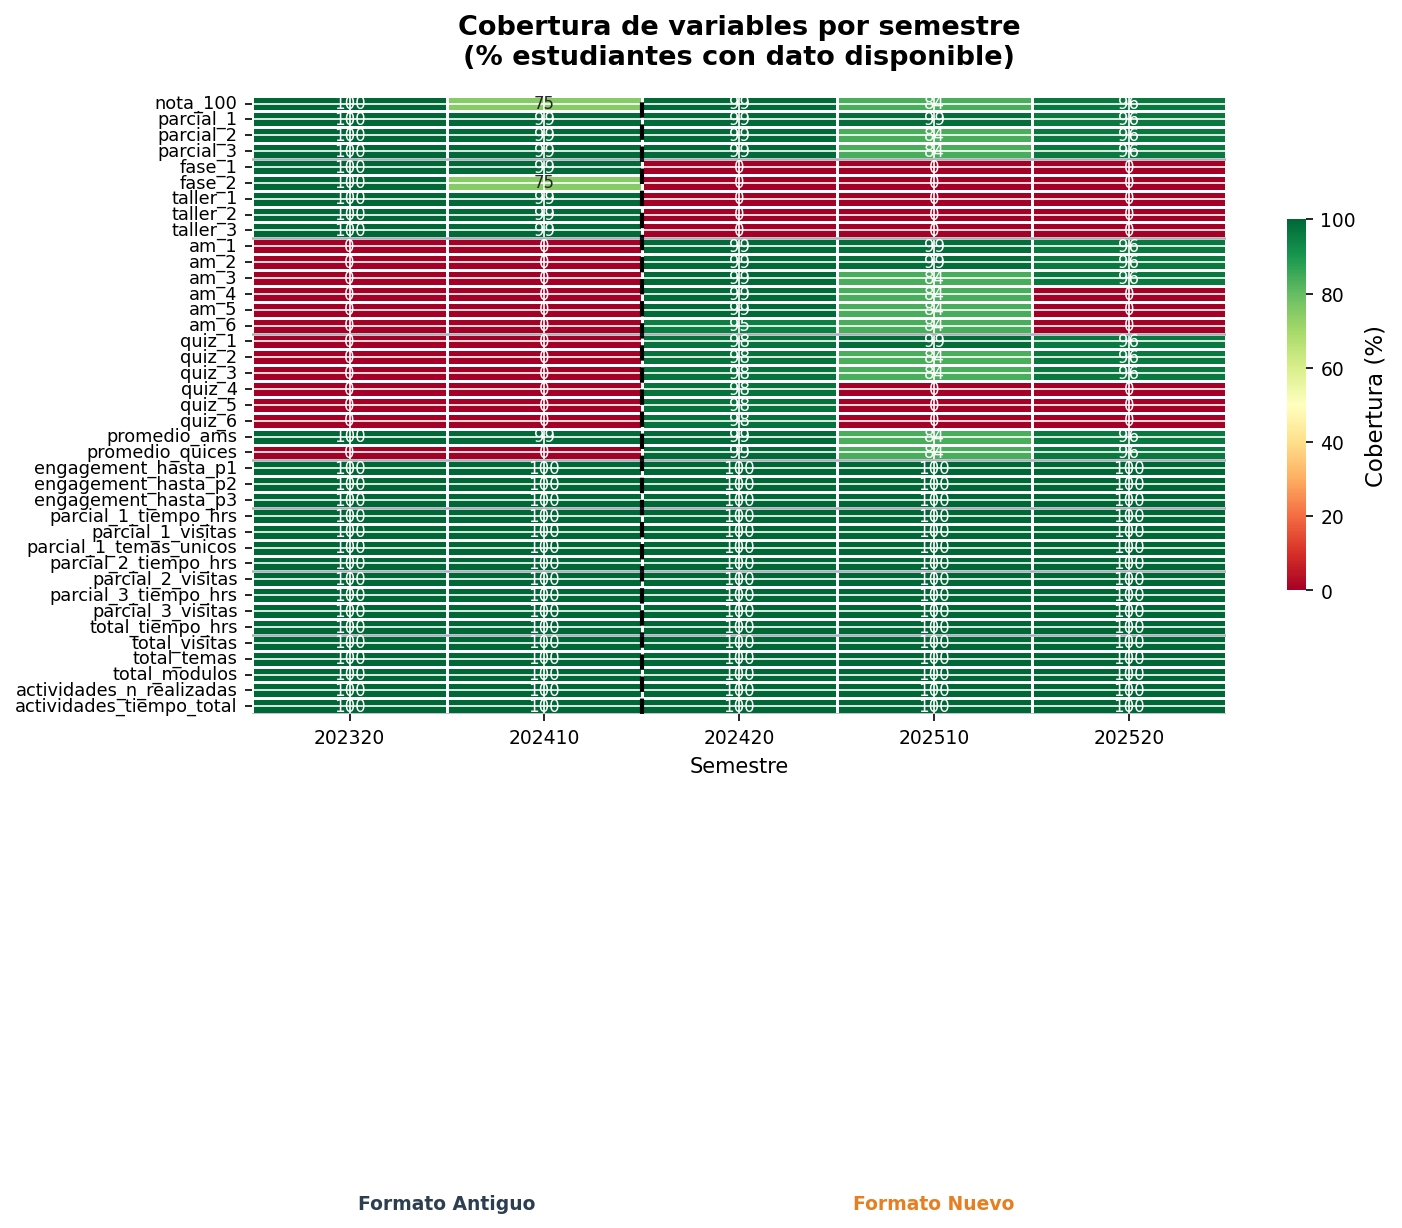

In [7]:
# ─── 3.1 Heatmap de cobertura (% datos disponibles) por variable y semestre ──

# Variables numéricas de interés (excluimos columnas de modo/_modo)
vars_analisis = [
    'nota_100', 'parcial_1', 'parcial_2', 'parcial_3',
    'fase_1', 'fase_2', 'taller_1', 'taller_2', 'taller_3',
    'am_1', 'am_2', 'am_3', 'am_4', 'am_5', 'am_6',
    'quiz_1', 'quiz_2', 'quiz_3', 'quiz_4', 'quiz_5', 'quiz_6',
    'promedio_ams', 'promedio_quices',
    'engagement_hasta_p1', 'engagement_hasta_p2', 'engagement_hasta_p3',
    'parcial_1_tiempo_hrs', 'parcial_1_visitas', 'parcial_1_temas_unicos',
    'parcial_2_tiempo_hrs', 'parcial_2_visitas',
    'parcial_3_tiempo_hrs', 'parcial_3_visitas',
    'total_tiempo_hrs', 'total_visitas', 'total_temas', 'total_modulos',
    'actividades_n_realizadas', 'actividades_tiempo_total',
]

# Cobertura: % de estudiantes con valor NO-nulo por semestre
cobertura = pd.DataFrame(index=vars_analisis, columns=semestres)
for sem in semestres:
    n_total = len(df[df['semestre'] == sem])
    for var in vars_analisis:
        n_validos = df[df['semestre'] == sem][var].notna().sum()
        cobertura.loc[var, sem] = round(n_validos / n_total * 100, 1)
cobertura = cobertura.astype(float)

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 13))

# Colormap: rojo = 0%, verde = 100%
cmap = sns.diverging_palette(10, 130, s=80, l=55, as_cmap=True)
sns.heatmap(
    cobertura,
    ax=ax,
    cmap='RdYlGn',
    vmin=0, vmax=100,
    annot=True, fmt='.0f',
    annot_kws={'size': 8},
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Cobertura (%)', 'shrink': 0.6}
)

ax.set_title('Cobertura de variables por semestre\n(% estudiantes con dato disponible)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Semestre', fontsize=10)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8.5)
ax.tick_params(axis='x', labelsize=9)

# Separador visual entre eras
ax.axvline(2, color='black', linewidth=2, linestyle='--')
ax.text(1.0, -0.8, 'Formato Antiguo', ha='center', transform=ax.get_xaxis_transform(),
        fontsize=9, color=PALETA_ERA['formato_antiguo'], fontweight='bold')
ax.text(3.5, -0.8, 'Formato Nuevo', ha='center', transform=ax.get_xaxis_transform(),
        fontsize=9, color=PALETA_ERA['formato_nuevo'], fontweight='bold')

# Separadores de grupos de variables
grupos = {
    'Notas finales': [0, 4],
    'Formato Antiguo': [4, 9],
    'AMs (Nuevo)': [9, 15],
    'Quices (Nuevo)': [15, 23],
    'Engagement acumulado': [23, 26],
    'Engagement P1': [26, 30],
    'Engagement P2/P3': [30, 34],
    'Engagement total': [34, 39],
}
for nombre, (inicio, fin) in grupos.items():
    ax.axhline(fin, color='#2c3e50', linewidth=1.2, linestyle='-', alpha=0.4)

plt.tight_layout()
plt.savefig('../figures/01_cobertura_variables_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

In [8]:
# ─── 3.2 Tabla de cobertura detallada con clasificación de nulo ───────────────
print("=" * 80)
print("CLASIFICACIÓN DE NULOS: ESTRUCTURALES vs. POTENCIALMENTE PROBLEMÁTICOS")
print("=" * 80)

# Nulos en df_activos (APROBÓ + REPROBÓ) - estos son los más críticos
nulos_activos = df_activos[vars_analisis].isnull().sum().sort_values(ascending=False)
nulos_activos_pct = (nulos_activos / len(df_activos) * 100).round(1)

print(f"\nNulos en df_activos (N={len(df_activos)} estudiantes activos):")
print(f"{'Variable':<35} {'N nulos':>8} {'% nulos':>8} {'Causa probable'}")
print("-" * 80)
for var in nulos_activos[nulos_activos > 0].index:
    n = nulos_activos[var]
    p = nulos_activos_pct[var]
    if var.startswith(('am_', 'quiz_')):
        causa = 'Estructural: no aplica en todos los semestres'
    elif var.startswith(('fase_', 'taller_')):
        causa = 'Estructural: solo formato antiguo'
    elif var == 'nota_100':
        causa = 'REVISAR: activos sin nota final'
    elif var.startswith('parcial_'):
        causa = 'REVISAR: activo sin nota de parcial'
    elif var.startswith(('promedio_', 'engagement_', 'total_', 'actividades_', 'parcial_1_', 'parcial_2_', 'parcial_3_')):
        causa = 'Engagement: sin registro en plataforma'
    else:
        causa = 'Revisar'
    print(f"{var:<35} {n:>8} {p:>7.1f}%  {causa}")

CLASIFICACIÓN DE NULOS: ESTRUCTURALES vs. POTENCIALMENTE PROBLEMÁTICOS

Nulos en df_activos (N=554 estudiantes activos):
Variable                             N nulos  % nulos Causa probable
--------------------------------------------------------------------------------
quiz_4                                   431    77.8%  Estructural: no aplica en todos los semestres
quiz_6                                   431    77.8%  Estructural: no aplica en todos los semestres
quiz_5                                   431    77.8%  Estructural: no aplica en todos los semestres
taller_2                                 329    59.4%  Estructural: solo formato antiguo
taller_1                                 329    59.4%  Estructural: solo formato antiguo
fase_2                                   329    59.4%  Estructural: solo formato antiguo
fase_1                                   329    59.4%  Estructural: solo formato antiguo
taller_3                                 329    59.4%  Estructural: so

---
## Sección 4 — Análisis de Outliers en Variables Clave

En este dataset existen **outliers legítimos** que no deben eliminarse:
- **Notas > 5.0**: Posibles por bonificaciones del profesor, especialmente en AMs. Son valores reales y deben conservarse.
- **Engagement muy alto** (>100 horas): Algunos estudiantes usan intensivamente la plataforma. Son valores extremos pero reales.

El objetivo es identificar la magnitud de estos valores para decidir estrategias de tratamiento en los modelos (escalado, winsorización, etc.), **no para eliminarlos**.

También se identificarán valores que podrían ser errores reales:
- Notas iguales a exactamente 0.0 en activos que no retiraron (¿ausencia a evaluación vs. dato faltante?).

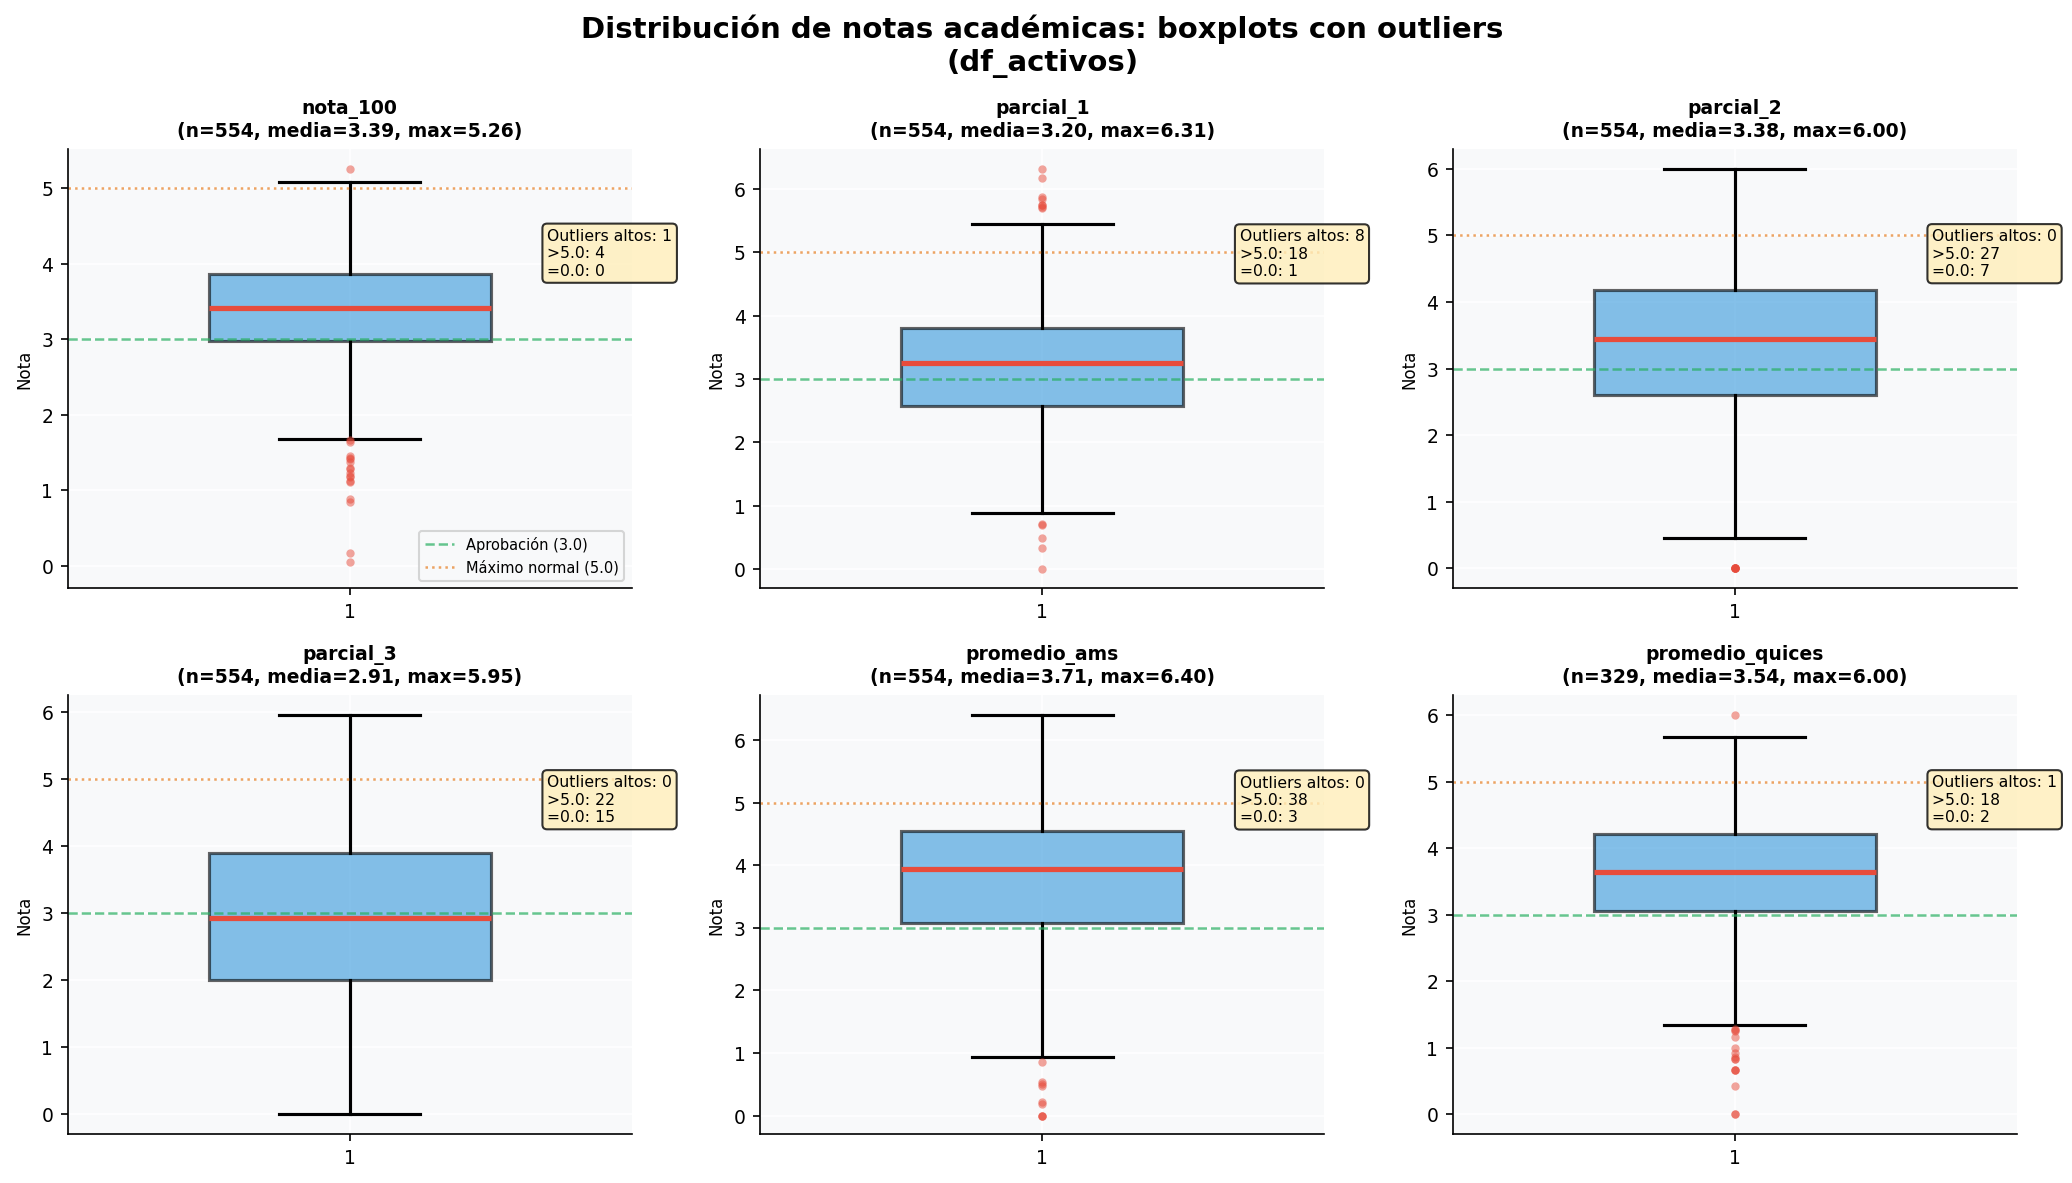

In [9]:
# ─── 4.1 Boxplots de notas con outliers anotados ─────────────────────────────
vars_notas = ['nota_100', 'parcial_1', 'parcial_2', 'parcial_3',
              'promedio_ams', 'promedio_quices']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribución de notas académicas: boxplots con outliers\n(df_activos)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, var in enumerate(vars_notas):
    ax = axes[i]
    data_plot = df_activos[var].dropna()

    # Boxplot con puntos
    parts = ax.boxplot(
        data_plot,
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='#3498db', alpha=0.6, linewidth=1.5),
        medianprops=dict(color='#e74c3c', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=4, alpha=0.5,
                        markerfacecolor='#e74c3c', markeredgecolor='none'),
        widths=0.5
    )

    # Línea de corte en 3.0 (aprobación) y 5.0 (máximo normal)
    ax.axhline(3.0, color='#27ae60', linestyle='--', alpha=0.7, linewidth=1.2, label='Aprobación (3.0)')
    ax.axhline(5.0, color='#e67e22', linestyle=':', alpha=0.7, linewidth=1.2, label='Máximo normal (5.0)')

    q1, q3 = data_plot.quantile(0.25), data_plot.quantile(0.75)
    iqr = q3 - q1
    n_outliers_high = (data_plot > q3 + 1.5*iqr).sum()
    n_above_5 = (data_plot > 5.0).sum()
    n_zero = (data_plot == 0.0).sum()

    ax.set_title(f'{var}\n(n={len(data_plot)}, media={data_plot.mean():.2f}, max={data_plot.max():.2f})',
                 fontsize=9, fontweight='bold')
    ax.set_ylim(-0.3, max(data_plot.max() * 1.05, 5.3))
    ax.set_ylabel('Nota', fontsize=8)

    # Anotaciones
    info_text = f'Outliers altos: {n_outliers_high}\n>5.0: {n_above_5}\n=0.0: {n_zero}'
    ax.text(1.35, data_plot.max() * 0.85, info_text,
            fontsize=7.5, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffeeba', alpha=0.8))

    if i == 0:
        ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig('../figures/01_outliers_notas.png', bbox_inches='tight', dpi=150)
plt.show()

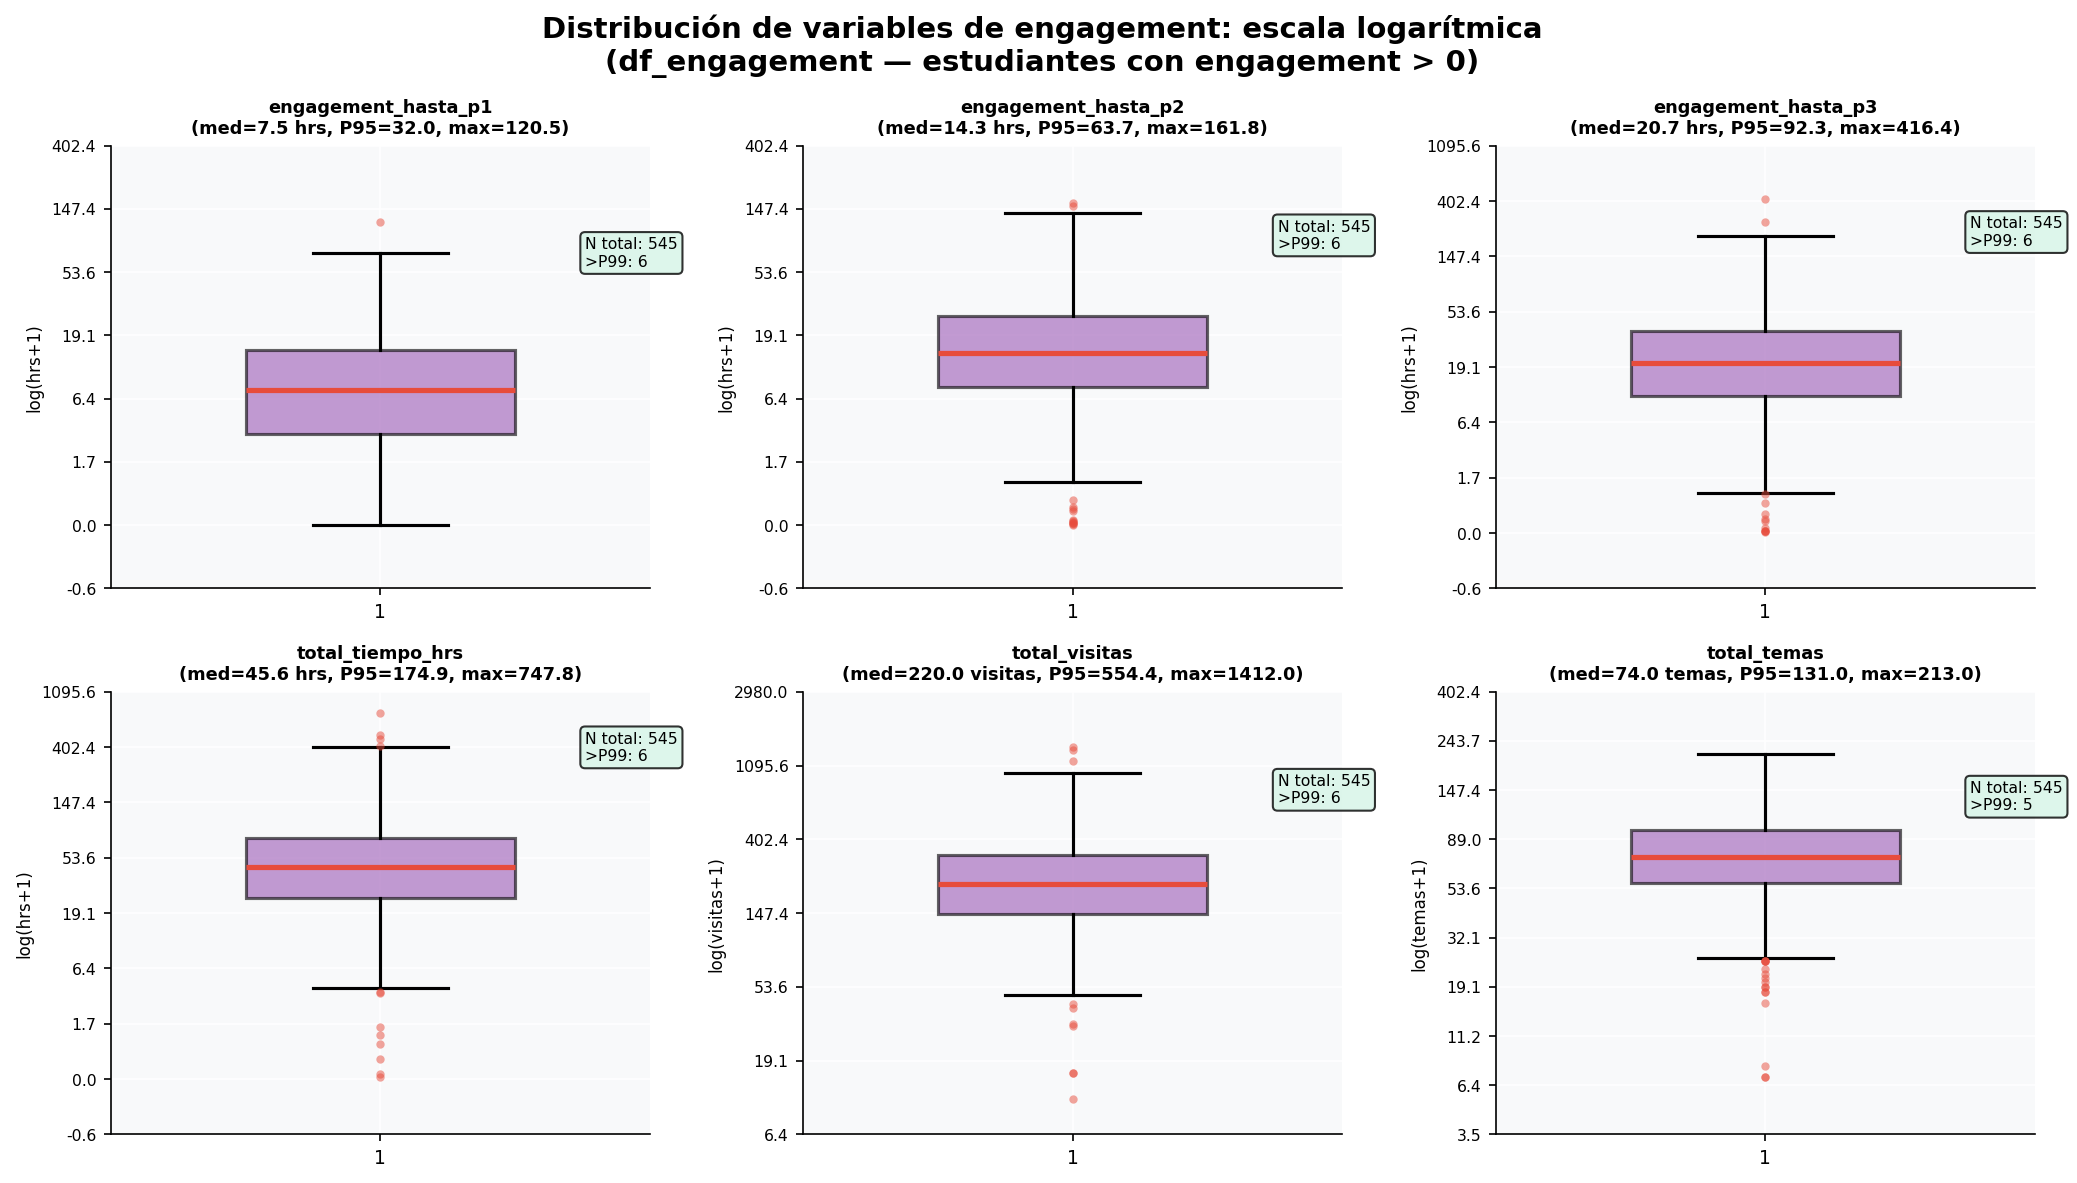

In [10]:
# ─── 4.2 Boxplots de engagement (escala log) ──────────────────────────────────
vars_eng = ['engagement_hasta_p1', 'engagement_hasta_p2', 'engagement_hasta_p3',
            'total_tiempo_hrs', 'total_visitas', 'total_temas']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribución de variables de engagement: escala logarítmica\n(df_engagement — estudiantes con engagement > 0)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, var in enumerate(vars_eng):
    ax = axes[i]
    data_log = np.log1p(df_engagement[var].dropna())
    data_orig = df_engagement[var].dropna()

    parts = ax.boxplot(
        data_log,
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='#9b59b6', alpha=0.6, linewidth=1.5),
        medianprops=dict(color='#e74c3c', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=4, alpha=0.5,
                        markerfacecolor='#e74c3c', markeredgecolor='none'),
        widths=0.5
    )

    # Etiquetas en escala original en el eje y
    yticks_log = ax.get_yticks()
    ax.set_yticks(yticks_log)
    ax.set_yticklabels([f'{np.expm1(v):.1f}' for v in yticks_log], fontsize=7.5)

    unidad = 'hrs' if 'tiempo' in var or 'engagement' in var else \
             'visitas' if 'visita' in var else 'temas'

    q95 = data_orig.quantile(0.95)
    q99 = data_orig.quantile(0.99)
    n_extremos = (data_orig > q99).sum()

    ax.set_title(
        f'{var}\n(med={data_orig.median():.1f} {unidad}, P95={q95:.1f}, max={data_orig.max():.1f})',
        fontsize=8.5, fontweight='bold'
    )
    ax.set_ylabel(f'log({unidad}+1)', fontsize=8)

    info_text = f'N total: {len(data_orig)}\n>P99: {n_extremos}'
    ax.text(1.38, data_log.max() * 0.95, info_text,
            fontsize=7.5, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#d5f4e6', alpha=0.8))

plt.tight_layout()
plt.savefig('../figures/01_outliers_engagement.png', bbox_inches='tight', dpi=150)
plt.show()

In [11]:
# ─── 4.3 Análisis de ceros en activos ────────────────────────────────────────
# Estudiantes activos con notas = 0 (¿ausencia real vs. dato faltante?)
print("=" * 65)
print("NOTAS IGUALES A 0.0 EN ESTUDIANTES ACTIVOS (APROBÓ/REPROBÓ)")
print("=" * 65)
for var in ['parcial_1', 'parcial_2', 'parcial_3']:
    ceros = df_activos[df_activos[var] == 0.0]
    if len(ceros) > 0:
        print(f"\n{var} = 0.0 en activos: {len(ceros)} estudiantes")
        print(ceros.groupby(['semestre', 'estado']).size().to_string())
print("\nInterpretación: parcial=0 en activos puede indicar ausencia a la evaluación")
print("(no retiro). Deben distinguirse de NaN (dato realmente faltante) en el modelado.")

NOTAS IGUALES A 0.0 EN ESTUDIANTES ACTIVOS (APROBÓ/REPROBÓ)

parcial_1 = 0.0 en activos: 1 estudiantes
semestre  estado  
202320    APROBÓ      0
          REPROBÓ     1
          RETIRADO    0
          SIN_NOTA    0

parcial_2 = 0.0 en activos: 7 estudiantes
semestre  estado  
202320    APROBÓ      0
          REPROBÓ     3
          RETIRADO    0
          SIN_NOTA    0
202410    APROBÓ      0
          REPROBÓ     1
          RETIRADO    0
          SIN_NOTA    0
202510    APROBÓ      0
          REPROBÓ     2
          RETIRADO    0
          SIN_NOTA    0
202520    APROBÓ      0
          REPROBÓ     1
          RETIRADO    0
          SIN_NOTA    0

parcial_3 = 0.0 en activos: 15 estudiantes
semestre  estado  
202320    APROBÓ      0
          REPROBÓ     3
          RETIRADO    0
          SIN_NOTA    0
202410    APROBÓ      0
          REPROBÓ     2
          RETIRADO    0
          SIN_NOTA    0
202420    APROBÓ      0
          REPROBÓ     1
          RETIRADO    0
         

---
## Sección 5 — Estructura de Variables y Disponibilidad por Checkpoint

Para diseñar correctamente los modelos de alerta temprana, es fundamental saber **qué información estará disponible en cada momento de intervención**. Los modelos operan en tres checkpoints:

| Checkpoint | Semana | Información disponible | Ventana de intervención |
|------------|--------|------------------------|-------------------------|
| CP1 | ~6 | Parcial 1 + AMs/quices previos + engagement P1 | ~11 semanas |
| CP2 | ~11 | CP1 + Parcial 2 + más AMs/quices + engagement P2 | ~6 semanas |
| CP3 | ~18 | Todos los datos | Post-mortem |

Esta sección mapea exactamente qué columnas del dataset corresponden a cada checkpoint y en qué semestres están disponibles.

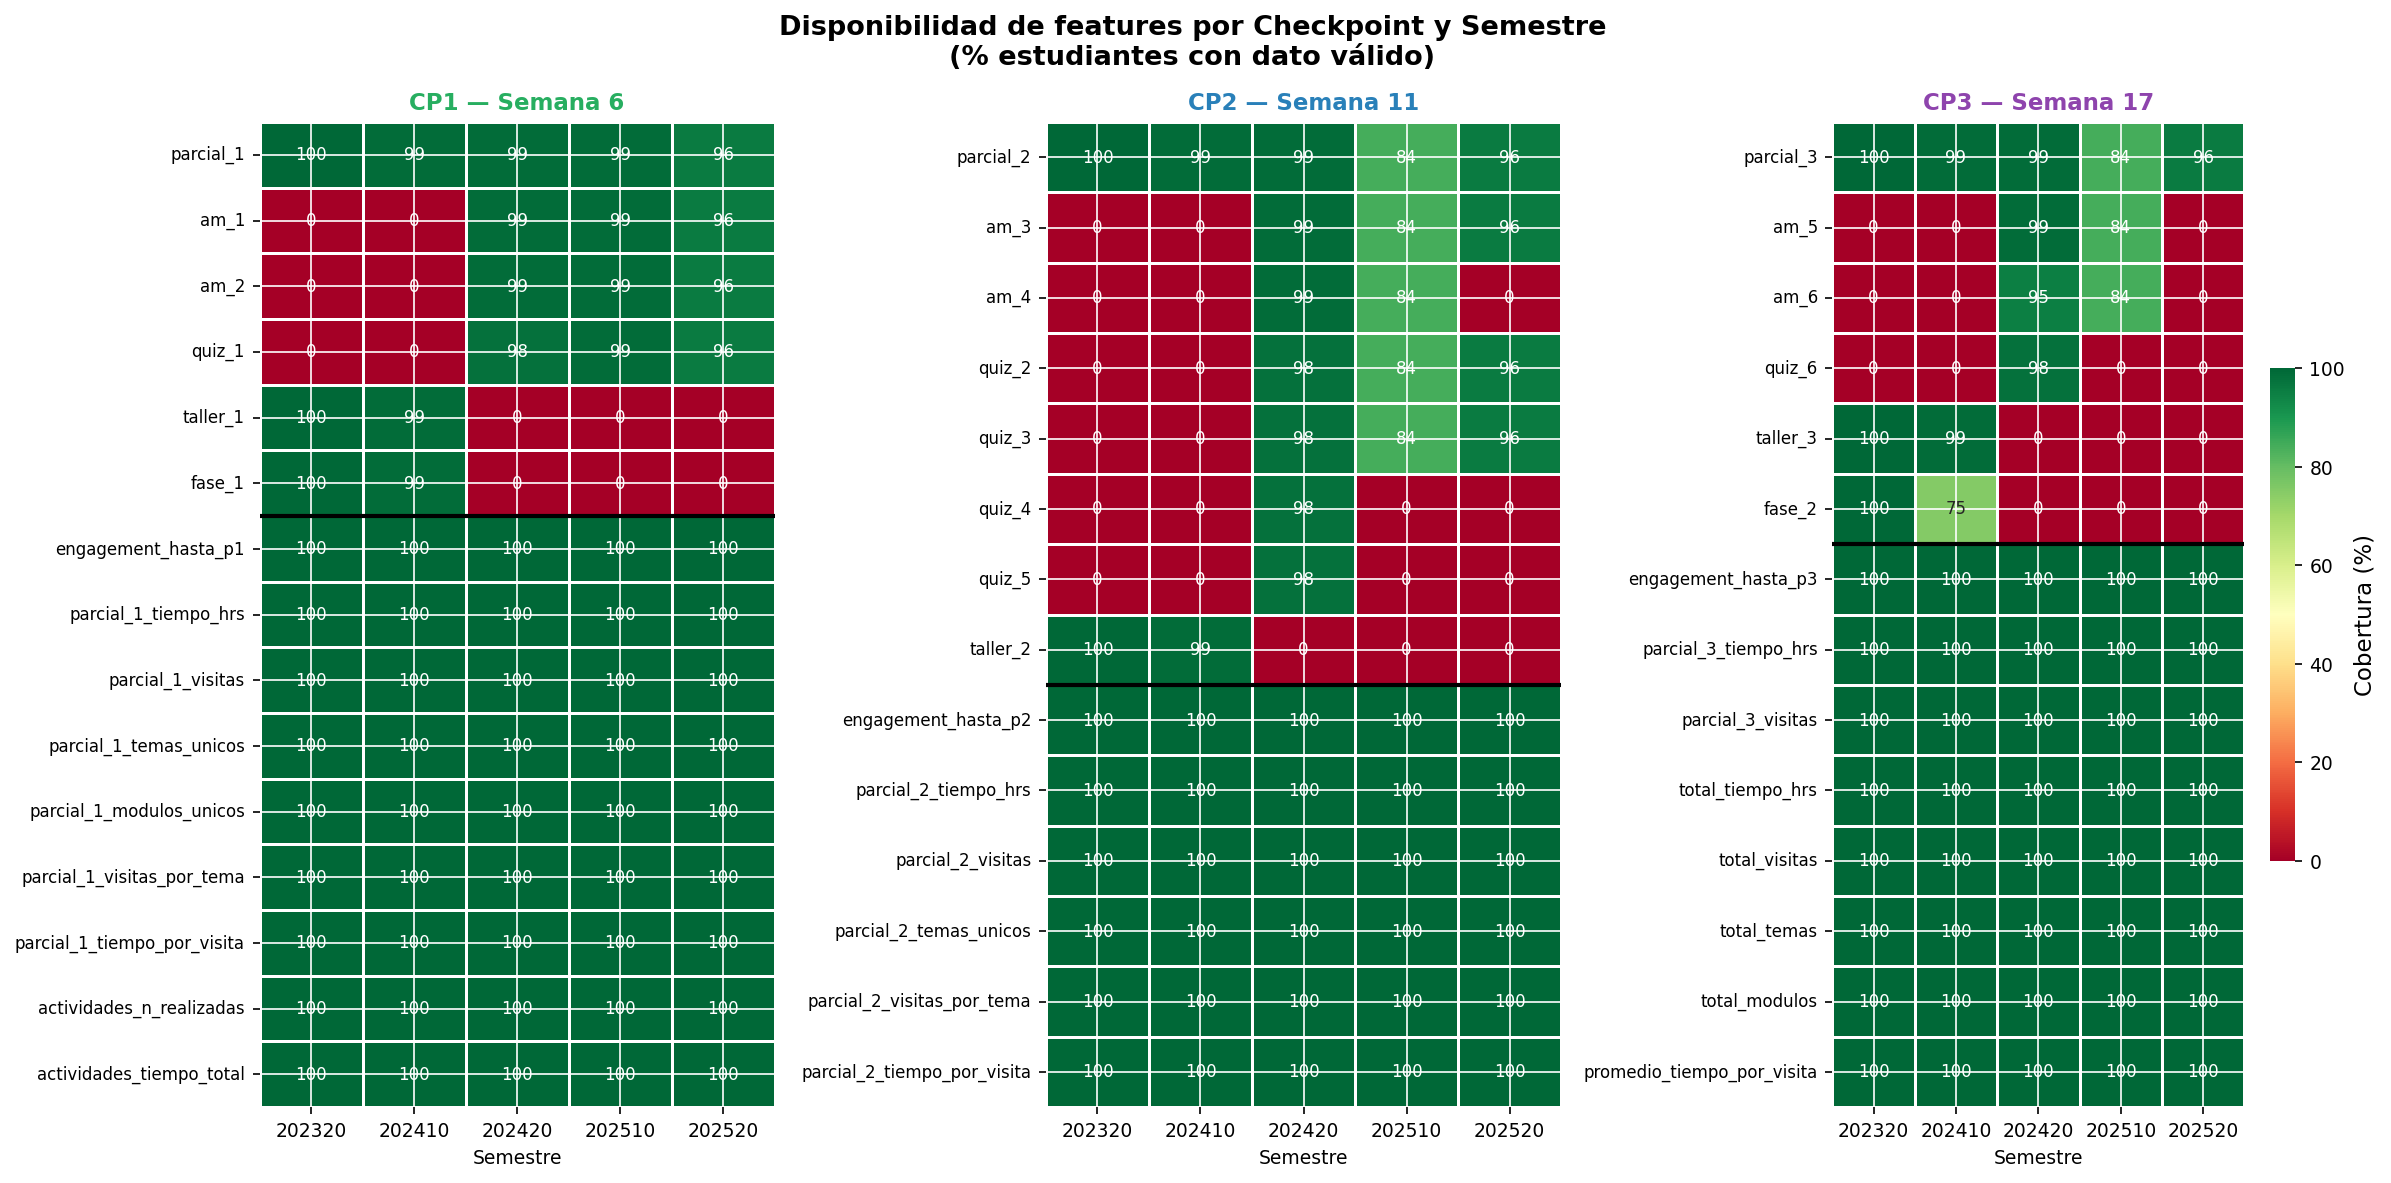

In [12]:
# ─── 5.1 Mapa de disponibilidad de variables por checkpoint y semestre ─────────

# Definición de features por checkpoint (basada en calendario de evaluaciones)
features_cp = {
    'CP1': {
        'Académicas': [
            'parcial_1',
            'am_1', 'am_2',        # Formato nuevo (según semestre)
            'quiz_1',              # Formato nuevo (según semestre)
            'taller_1',            # Formato antiguo
            'fase_1',              # Formato antiguo
        ],
        'Engagement': [
            'engagement_hasta_p1',
            'parcial_1_tiempo_hrs',
            'parcial_1_visitas',
            'parcial_1_temas_unicos',
            'parcial_1_modulos_unicos',
            'parcial_1_visitas_por_tema',
            'parcial_1_tiempo_por_visita',
            'actividades_n_realizadas',
            'actividades_tiempo_total',
        ]
    },
    'CP2': {
        'Académicas': [
            'parcial_2',
            'am_3', 'am_4',
            'quiz_2', 'quiz_3', 'quiz_4', 'quiz_5',
            'taller_2',
        ],
        'Engagement': [
            'engagement_hasta_p2',
            'parcial_2_tiempo_hrs',
            'parcial_2_visitas',
            'parcial_2_temas_unicos',
            'parcial_2_visitas_por_tema',
            'parcial_2_tiempo_por_visita',
        ]
    },
    'CP3': {
        'Académicas': [
            'parcial_3',
            'am_5', 'am_6',
            'quiz_6', 'taller_3', 'fase_2',
        ],
        'Engagement': [
            'engagement_hasta_p3',
            'parcial_3_tiempo_hrs',
            'parcial_3_visitas',
            'total_tiempo_hrs',
            'total_visitas',
            'total_temas',
            'total_modulos',
            'promedio_tiempo_por_visita',
        ]
    }
}

# Calcular disponibilidad de cada feature por semestre
all_features = []
for cp, grupos in features_cp.items():
    for grupo, feats in grupos.items():
        for feat in feats:
            if feat in df.columns:
                row = {'checkpoint': cp, 'grupo': grupo, 'feature': feat}
                for sem in semestres:
                    n_total = len(df[df['semestre']==sem])
                    n_valid = df[df['semestre']==sem][feat].notna().sum()
                    pct = round(n_valid/n_total*100)
                    row[str(sem)] = pct
                all_features.append(row)

df_features = pd.DataFrame(all_features)

# Visualizar como heatmap por checkpoint
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
fig.suptitle('Disponibilidad de features por Checkpoint y Semestre\n(% estudiantes con dato válido)',
             fontsize=13, fontweight='bold')

cp_colors = {'CP1': '#27ae60', 'CP2': '#2980b9', 'CP3': '#8e44ad'}

for ax, cp in zip(axes, ['CP1', 'CP2', 'CP3']):
    sub = df_features[df_features['checkpoint'] == cp].copy()
    sub.index = sub['feature']
    mat = sub[[str(s) for s in semestres]].astype(float)

    sns.heatmap(
        mat, ax=ax,
        cmap='RdYlGn', vmin=0, vmax=100,
        annot=True, fmt='.0f',
        annot_kws={'size': 8},
        linewidths=0.5, linecolor='white',
        cbar=(cp == 'CP3'),
        cbar_kws={'label': 'Cobertura (%)', 'shrink': 0.5} if cp == 'CP3' else {}
    )
    ax.set_title(f'{cp} — Semana {"6" if cp=="CP1" else "11" if cp=="CP2" else "17"}',
                 fontsize=11, fontweight='bold', color=cp_colors[cp])
    ax.set_xlabel('Semestre', fontsize=9)
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=8)

    # Separador académicas / engagement
    n_acad = len(features_cp[cp]['Académicas'])
    if n_acad < len(sub):
        ax.axhline(n_acad, color='black', linewidth=2)

plt.tight_layout()
plt.savefig('../figures/01_features_por_checkpoint.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Sección 6 — Perfil Estadístico por Era y Semestre

Esta sección presenta un **perfil estadístico completo** del dataset desagregado por era y semestre. El objetivo es detectar diferencias sistemáticas entre grupos que puedan afectar la comparabilidad de los modelos y que deben tenerse en cuenta al definir la estrategia de entrenamiento/validación.

Se analiza: tamaño del grupo, nota promedio, dispersión, tasa de aprobación, y engagement promedio por cada agrupación.

In [13]:
# ─── 6.1 Tabla de estadísticos descriptivos clave por semestre ────────────────
print("=" * 100)
print("PERFIL ESTADÍSTICO POR SEMESTRE (df_activos)")
print("=" * 100)

resumen_sem = []
for sem in semestres:
    sub = df_activos[df_activos['semestre'] == sem]
    sub_eng = df_activos_engagement[df_activos_engagement['semestre'] == sem]
    era = sub['era'].iloc[0]

    row = {
        'Semestre': sem,
        'Era': 'Antiguo' if era == 'formato_antiguo' else 'Nuevo',
        'N activos': len(sub),
        'N con eng.': len(sub_eng),
        'Tasa aprob. (%)': round(sub['estado'].value_counts(normalize=True).get('APROBÓ', 0)*100, 1),
        'Nota media': round(sub['nota_100'].mean(), 3),
        'Nota mediana': round(sub['nota_100'].median(), 3),
        'Nota std': round(sub['nota_100'].std(), 3),
        'P1 media': round(sub['parcial_1'].mean(), 3),
        'P1 std': round(sub['parcial_1'].std(), 3),
        'P2 media': round(sub['parcial_2'].mean(), 3),
        'P3 media': round(sub['parcial_3'].mean(), 3),
        'Eng. P1 med. (h)': round(sub_eng['engagement_hasta_p1'].median(), 2) if len(sub_eng)>0 else np.nan,
        'Total hrs med.': round(sub_eng['total_tiempo_hrs'].median(), 2) if len(sub_eng)>0 else np.nan,
    }
    resumen_sem.append(row)

df_resumen = pd.DataFrame(resumen_sem)
print(df_resumen.to_string(index=False))

PERFIL ESTADÍSTICO POR SEMESTRE (df_activos)
 Semestre     Era  N activos  N con eng.  Tasa aprob. (%)  Nota media  Nota mediana  Nota std  P1 media  P1 std  P2 media  P3 media  Eng. P1 med. (h)  Total hrs med.
   202320 Antiguo        143         107             81.1       3.550         3.610     0.745     3.398   1.179     2.945     3.302              9.35           63.98
   202410 Antiguo         82          72             82.9       3.508         3.500     0.745     3.211   0.927     3.158     3.093             14.46           75.24
   202420   Nuevo        123         120             73.2       3.364         3.420     0.731     3.051   0.842     3.590     2.985              5.80           44.73
   202510   Nuevo        117         114             59.8       3.047         3.100     0.701     3.262   0.904     3.177     1.769              5.43           25.74
   202520   Nuevo         89          89             77.5       3.524         3.501     0.921     3.005   0.831     4.254    

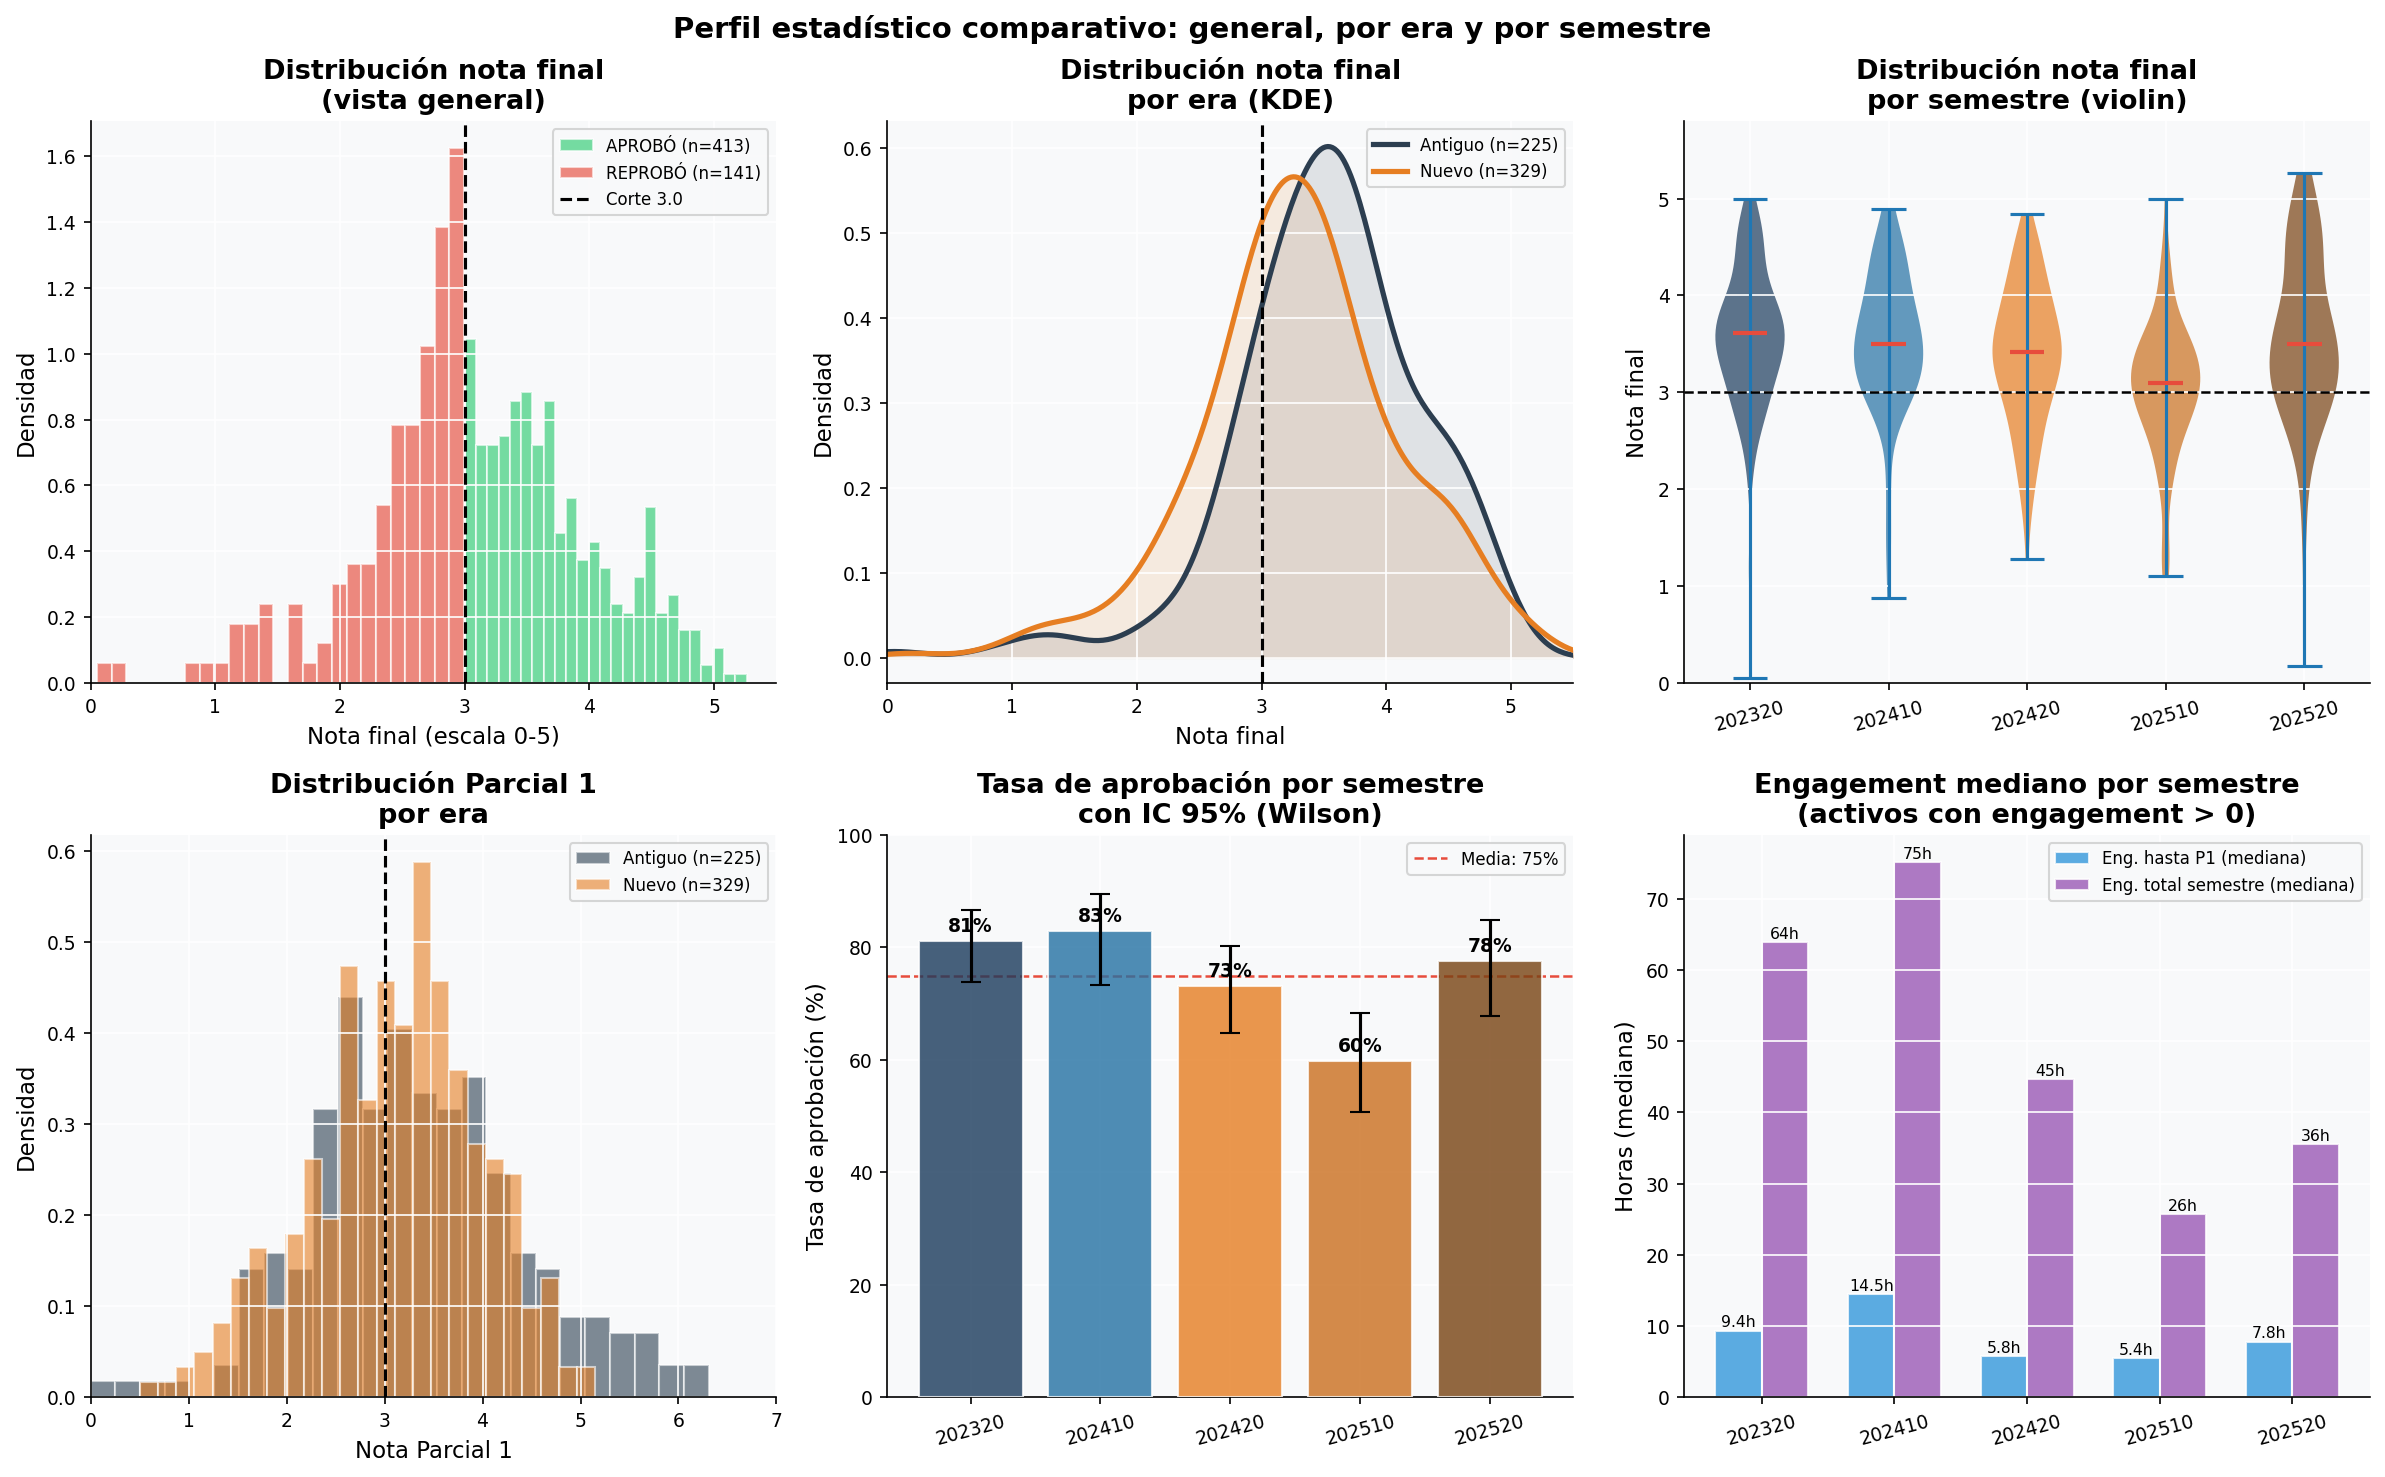

In [14]:
# ─── 6.2 Visualización: Panel comparativo general vs. era vs. semestre ─────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Perfil estadístico comparativo: general, por era y por semestre',
             fontsize=14, fontweight='bold')

# ── A: Nota final - distribución general ─────────────────────────────────────
ax = axes[0, 0]
for estado in ['APROBÓ', 'REPROBÓ']:
    data_e = df_activos[df_activos['estado']==estado]['nota_100'].dropna()
    ax.hist(data_e, bins=25, alpha=0.65, color=PALETA_ESTADO[estado],
            label=f"{estado} (n={len(data_e)})", edgecolor='white', density=True)
ax.axvline(3.0, color='black', linestyle='--', linewidth=1.5, label='Corte 3.0')
ax.set_xlabel('Nota final (escala 0-5)')
ax.set_ylabel('Densidad')
ax.set_xlim(0, 5.5)
ax.set_title('Distribución nota final\n(vista general)', fontweight='bold')
ax.legend(fontsize=8)

# ── B: Nota final por era - KDE ───────────────────────────────────────────────
ax2 = axes[0, 1]
for era in ['formato_antiguo', 'formato_nuevo']:
    data_e = df_activos[df_activos['era']==era]['nota_100'].dropna()
    label = f"{'Antiguo' if era=='formato_antiguo' else 'Nuevo'} (n={len(data_e)})"
    # KDE manual
    kde_x = np.linspace(0, 5.5, 300)
    from scipy.stats import gaussian_kde
    try:
        kde = gaussian_kde(data_e)
        ax2.plot(kde_x, kde(kde_x), linewidth=2.5, color=PALETA_ERA[era], label=label)
        ax2.fill_between(kde_x, kde(kde_x), alpha=0.12, color=PALETA_ERA[era])
    except Exception:
        pass
ax2.axvline(3.0, color='black', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Nota final')
ax2.set_ylabel('Densidad')
ax2.set_xlim(0, 5.5)
ax2.set_title('Distribución nota final\npor era (KDE)', fontweight='bold')
ax2.legend(fontsize=8)

# ── C: Nota final por semestre - violin ──────────────────────────────────────
ax3 = axes[0, 2]
data_violin = [df_activos[df_activos['semestre']==s]['nota_100'].dropna().values for s in semestres]
parts = ax3.violinplot(data_violin, positions=range(len(semestres)),
                       showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    sem = semestres[i]
    pc.set_facecolor(PALETA_SEMESTRE[sem])
    pc.set_alpha(0.7)
parts['cmedians'].set_color('#e74c3c')
parts['cmedians'].set_linewidth(2)
ax3.axhline(3.0, color='black', linestyle='--', linewidth=1.2)
ax3.set_xticks(range(len(semestres)))
ax3.set_xticklabels([str(s) for s in semestres], rotation=15)
ax3.set_ylabel('Nota final')
ax3.set_ylim(0, 5.8)
ax3.set_title('Distribución nota final\npor semestre (violin)', fontweight='bold')

# ── D: Parcial 1 por era ───────────────────────────────────────────────────────
ax4 = axes[1, 0]
for era in ['formato_antiguo', 'formato_nuevo']:
    data_e = df_activos[df_activos['era']==era]['parcial_1'].dropna()
    label = f"{'Antiguo' if era=='formato_antiguo' else 'Nuevo'} (n={len(data_e)})"
    ax4.hist(data_e, bins=25, alpha=0.6, color=PALETA_ERA[era],
             label=label, edgecolor='white', density=True)
ax4.axvline(3.0, color='black', linestyle='--', linewidth=1.5)
ax4.set_xlabel('Nota Parcial 1')
ax4.set_ylabel('Densidad')
ax4.set_xlim(0, 7)
ax4.set_title('Distribución Parcial 1\npor era', fontweight='bold')
ax4.legend(fontsize=8)

# ── E: Tasa de aprobación por semestre con IC (Wilson) ────────────────────────
ax5 = axes[1, 1]
tasas_aprob = []
ic_low, ic_high = [], []
for sem in semestres:
    sub_s = df_activos[df_activos['semestre']==sem]
    n_aprob = (sub_s['estado']=='APROBÓ').sum()
    n_total_s = len(sub_s)
    p = n_aprob / n_total_s
    tasas_aprob.append(p * 100)
    # Intervalo de confianza de Wilson (95%)
    z = 1.96
    center = (p + z**2/(2*n_total_s)) / (1 + z**2/n_total_s)
    margin = z * np.sqrt(p*(1-p)/n_total_s + z**2/(4*n_total_s**2)) / (1 + z**2/n_total_s)
    ic_low.append(max(0, (center - margin)) * 100)
    ic_high.append(min(1, (center + margin)) * 100)

x5 = range(len(semestres))
bars5 = ax5.bar(x5, tasas_aprob,
                color=[PALETA_SEMESTRE[s] for s in semestres],
                alpha=0.8, edgecolor='white', zorder=3)
ax5.errorbar(x5, tasas_aprob,
             yerr=[np.array(tasas_aprob)-np.array(ic_low),
                   np.array(ic_high)-np.array(tasas_aprob)],
             fmt='none', color='black', capsize=5, linewidth=1.5, zorder=4)
for bar, t in zip(bars5, tasas_aprob):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{t:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax5.set_xticks(x5)
ax5.set_xticklabels([str(s) for s in semestres], rotation=15)
ax5.set_ylabel('Tasa de aprobación (%)')
ax5.set_ylim(0, 100)
ax5.set_title('Tasa de aprobación por semestre\ncon IC 95% (Wilson)', fontweight='bold')
ax5.axhline(np.mean(tasas_aprob), color='#e74c3c', linestyle='--',
            linewidth=1.2, label=f'Media: {np.mean(tasas_aprob):.0f}%')
ax5.legend(fontsize=8)

# ── F: Engagement mediano por era y semestre ──────────────────────────────────
ax6 = axes[1, 2]
eng_p1_sem = [
    df_activos_engagement[df_activos_engagement['semestre']==s]['engagement_hasta_p1'].median()
    for s in semestres
]
eng_total_sem = [
    df_activos_engagement[df_activos_engagement['semestre']==s]['total_tiempo_hrs'].median()
    for s in semestres
]

x6 = np.arange(len(semestres))
w6 = 0.35
b1 = ax6.bar(x6 - w6/2, eng_p1_sem, width=w6, color='#3498db', alpha=0.8,
             label='Eng. hasta P1 (mediana)', edgecolor='white')
b2 = ax6.bar(x6 + w6/2, eng_total_sem, width=w6, color='#9b59b6', alpha=0.8,
             label='Eng. total semestre (mediana)', edgecolor='white')
for bar, v in zip(b1, eng_p1_sem):
    if not np.isnan(v):
        ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{v:.1f}h', ha='center', va='bottom', fontsize=7.5)
for bar, v in zip(b2, eng_total_sem):
    if not np.isnan(v):
        ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{v:.0f}h', ha='center', va='bottom', fontsize=7.5)
ax6.set_xticks(x6)
ax6.set_xticklabels([str(s) for s in semestres], rotation=15)
ax6.set_ylabel('Horas (mediana)')
ax6.set_title('Engagement mediano por semestre\n(activos con engagement > 0)', fontweight='bold')
ax6.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/01_perfil_estadistico_comparativo.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Sección 7 — Modalidad de Evaluación: Individual vs. Grupal

Una característica particular del dataset es que las **Actividades Magistrales cambiaron de modalidad** entre semestres. En 202420 las AMs eran evaluaciones **grupales**, mientras que en 202510 y 202520 pasaron a ser **individuales**. Esto es relevante porque las notas grupales tienen una distribución diferente (menos varianza, tendencia a ser más altas) y no son directamente comparables con las individuales.

Esta sección mapea la modalidad de cada tipo de evaluación para identificar qué variables pueden compararse directamente entre semestres y cuáles requieren manejo especial en los modelos.

In [15]:
# ─── 7.1 Mapa de modalidades por evaluación y semestre ────────────────────────
vars_modo = [
    ('am_1','am_1_modo'), ('am_2','am_2_modo'), ('am_3','am_3_modo'),
    ('am_4','am_4_modo'), ('am_5','am_5_modo'), ('am_6','am_6_modo'),
    ('quiz_1','quiz_1_modo'), ('quiz_2','quiz_2_modo'), ('quiz_3','quiz_3_modo'),
    ('quiz_4','quiz_4_modo'), ('quiz_5','quiz_5_modo'), ('quiz_6','quiz_6_modo'),
    ('taller_1','taller_1_modo'), ('taller_2','taller_2_modo'), ('taller_3','taller_3_modo'),
    ('fase_1','fase_1_modo'), ('fase_2','fase_2_modo'),
    ('parcial_1','parcial_1_modo'), ('parcial_2','parcial_2_modo'), ('parcial_3','parcial_3_modo'),
]

print("=" * 85)
print("MODALIDAD DE EVALUACIÓN POR SEMESTRE (ind=Individual, grup=Grupal, —=No aplica)")
print("=" * 85)
print(f"{'Evaluación':<15}", end='')
for s in semestres:
    print(f"{str(s):>12}", end='')
print()
print("-" * 85)

for nota_col, modo_col in vars_modo:
    row_str = f"{nota_col:<15}"
    for sem in semestres:
        sub_s = df[df['semestre']==sem]
        modos = sub_s[modo_col].dropna().unique()
        if len(modos) == 0:
            cell = '—'
        else:
            cell = '/'.join(sorted(set(modos)))
        row_str += f"{cell:>12}"
    print(row_str)

MODALIDAD DE EVALUACIÓN POR SEMESTRE (ind=Individual, grup=Grupal, —=No aplica)
Evaluación           202320      202410      202420      202510      202520
-------------------------------------------------------------------------------------
am_1                      —           —        grup         ind         ind
am_2                      —           —        grup         ind         ind
am_3                      —           —        grup         ind         ind
am_4                      —           —        grup         ind           —
am_5                      —           —        grup         ind           —
am_6                      —           —        grup         ind           —
quiz_1                    —           —         ind         ind         ind
quiz_2                    —           —         ind         ind         ind
quiz_3                    —           —         ind         ind         ind
quiz_4                    —           —         ind           —           

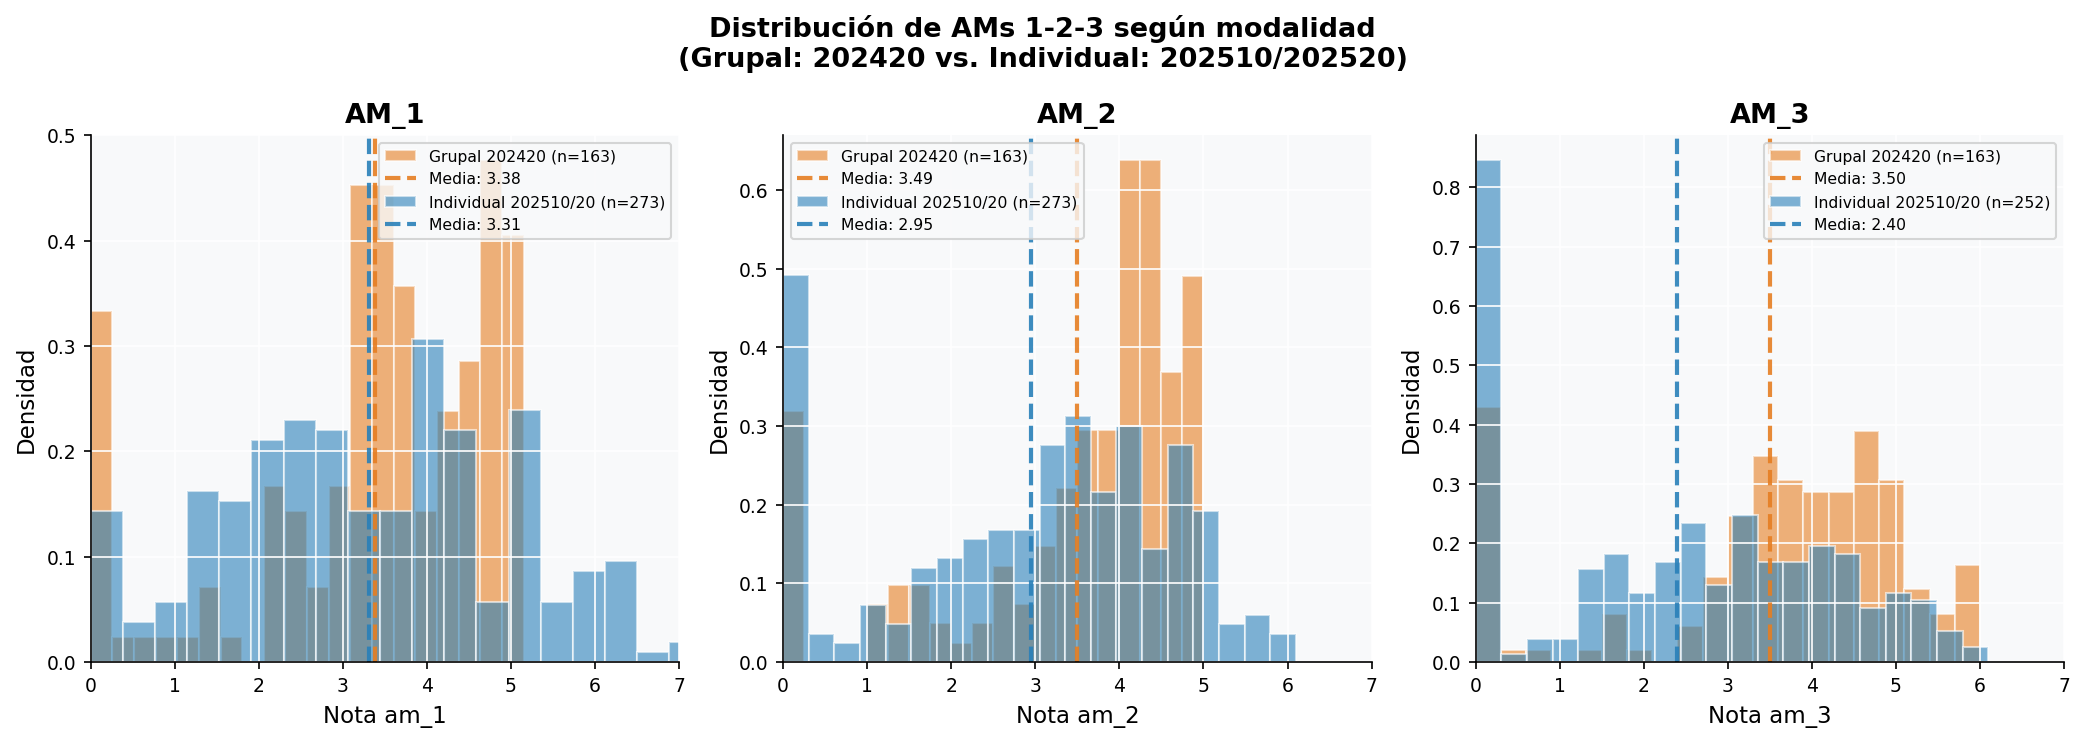

Observación: Las AMs grupales tienden a tener distribuciones más concentradas
y medias más altas vs. las individuales — esto debe controlarse en los modelos.


In [16]:
# ─── 7.2 Comparación de distribuciones según modalidad (AMs) ─────────────────
# Las AMs son el único caso donde la MISMA evaluación cambió de modo

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Distribución de AMs 1-2-3 según modalidad\n(Grupal: 202420 vs. Individual: 202510/202520)',
             fontsize=13, fontweight='bold')

for i, am_col in enumerate(['am_1', 'am_2', 'am_3']):
    ax = axes[i]
    for era_k, sems, color in [
        ('formato_nuevo_grupal', [202420], '#e67e22'),
        ('formato_nuevo_ind',    [202510, 202520], '#2980b9'),
    ]:
        data_e = df[df['semestre'].isin(sems)][am_col].dropna()
        label = f"Grupal 202420 (n={len(data_e)})" if 202420 in sems else \
                f"Individual 202510/20 (n={len(data_e)})"
        ax.hist(data_e, bins=20, alpha=0.6, color=color, label=label,
                edgecolor='white', density=True)
        ax.axvline(data_e.mean(), color=color, linestyle='--', linewidth=2,
                   alpha=0.9, label=f'Media: {data_e.mean():.2f}')
    ax.set_xlabel(f'Nota {am_col}')
    ax.set_ylabel('Densidad')
    ax.set_xlim(0, 7)
    ax.set_title(f'{am_col.upper()}', fontweight='bold')
    ax.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig('../figures/01_modalidad_ams.png', bbox_inches='tight', dpi=150)
plt.show()
print("Observación: Las AMs grupales tienden a tener distribuciones más concentradas")
print("y medias más altas vs. las individuales — esto debe controlarse en los modelos.")

---
## Sección 8 — Síntesis Final: Guía de Referencia del Dataset

Esta sección consolida los hallazgos de las secciones anteriores en una **guía de referencia rápida** para los notebooks de análisis posteriores. Establece los criterios definitivos para el uso de cada subconjunto y variables.

In [17]:
# ─── 8.1 Resumen de hallazgos y guía de uso ──────────────────────────────────
print("="*70)
print("SÍNTESIS DEL PERFIL DEL DATASET — PUNTOS CLAVE")
print("="*70)

print("""
COMPOSICIÓN:
  • 764 registros totales en 5 semestres (202320–202520)
  • 2 eras pedagógicas: Antiguo (320) y Nuevo (444)
  • 554 activos (APROBÓ + REPROBÓ); 164 retirados; 46 sin nota

TASAS (sobre total por semestre):
  • Tasa de aprobación varía: ver gráfico — tendencia a la baja en 202510
  • Tasa de retiro más alta en 202520 (>30% del total)
  • Los retirados NO tienen engagement ni notas válidas

SUBCONJUNTOS DE TRABAJO (usar según análisis):
  • df_all (764):                Tasas, distribución de estados, composición
  • df_activos (554):            Notas académicas, distribuciones, trayectorias
  • df_engagement (545):         Patrones de uso de plataforma
  • df_activos_engagement (502): Correlaciones nota-engagement, features ML

VARIABLES UNIVERSALES (todos los semestres):
  • parcial_1, parcial_2, parcial_3 → comparables entre semestres
  • nota_100, estado               → target del modelo
  • Todas las métricas de engagement de Bloque Neón

VARIABLES ERA-ESPECÍFICAS (no comparar directamente entre eras):
  • taller_1/2/3, fase_1/2  → solo formato antiguo (202320, 202410)
  • am_1..am_6, quiz_1..6   → solo formato nuevo (202420+)
  • am_1/2/3 en 202420      → GRUPAL (diferente distribución que 202510/20)

OUTLIERS LEGÍTIMOS:
  • Notas > 5.0: por bonos del profesor — NO eliminar
  • Engagement > 100 hrs: uso intensivo real — tratar con escalado robusto
  • Parcial = 0.0 en activos: ausencia a evaluación — distinguir de NaN

IMPLICACIONES PARA MODELADO:
  • Estrategia de validación: temporal (train en pasado, test en futuro)
  • Variable 'era' debe incluirse como control en modelos cross-era
  • Engagement = 0 en activos: señal de riesgo, NO dato faltante
  • CP1 disponible en todos los semestres con parcial_1 + engagement P1
""")
print("="*70)

SÍNTESIS DEL PERFIL DEL DATASET — PUNTOS CLAVE

COMPOSICIÓN:
  • 764 registros totales en 5 semestres (202320–202520)
  • 2 eras pedagógicas: Antiguo (320) y Nuevo (444)
  • 554 activos (APROBÓ + REPROBÓ); 164 retirados; 46 sin nota

TASAS (sobre total por semestre):
  • Tasa de aprobación varía: ver gráfico — tendencia a la baja en 202510
  • Tasa de retiro más alta en 202520 (>30% del total)
  • Los retirados NO tienen engagement ni notas válidas

SUBCONJUNTOS DE TRABAJO (usar según análisis):
  • df_all (764):                Tasas, distribución de estados, composición
  • df_activos (554):            Notas académicas, distribuciones, trayectorias
  • df_engagement (545):         Patrones de uso de plataforma
  • df_activos_engagement (502): Correlaciones nota-engagement, features ML

VARIABLES UNIVERSALES (todos los semestres):
  • parcial_1, parcial_2, parcial_3 → comparables entre semestres
  • nota_100, estado               → target del modelo
  • Todas las métricas de engagement

In [18]:
# ─── 8.2 Guardar subconjuntos para reuso en notebooks posteriores ─────────────
import os
os.makedirs('../data/subsets', exist_ok=True)

df_all.to_csv('../data/subsets/df_all.csv', index=False)
df_activos.to_csv('../data/subsets/df_activos.csv', index=False)
df_engagement.to_csv('../data/subsets/df_engagement.csv', index=False)
df_activos_engagement.to_csv('../data/subsets/df_activos_engagement.csv', index=False)

print("Subconjuntos guardados en ../data/subsets/")
print(f"  df_all:                {len(df_all)} filas × {df_all.shape[1]} cols")
print(f"  df_activos:            {len(df_activos)} filas × {df_activos.shape[1]} cols")
print(f"  df_engagement:         {len(df_engagement)} filas × {df_engagement.shape[1]} cols")
print(f"  df_activos_engagement: {len(df_activos_engagement)} filas × {df_activos_engagement.shape[1]} cols")
print("\nNotebook 01 completado. Continuar con: 02_analisis_notas_academicas.ipynb")

Subconjuntos guardados en ../data/subsets/
  df_all:                764 filas × 77 cols
  df_activos:            554 filas × 77 cols
  df_engagement:         545 filas × 77 cols
  df_activos_engagement: 502 filas × 77 cols

Notebook 01 completado. Continuar con: 02_analisis_notas_academicas.ipynb
